## show the data collection steps

## show the data cleaning steps and data aligning steps

## show the data labelling steps

## show the EDA step

In [1]:
import pandas as pd

merged_df = pd.read_csv(r"C:\Personal\Capstone\merged_df_copy.csv")

C:\Users\naman\AppData\Local\Temp\ipykernel_4860\2048760861.py:3: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_df = pd.read_csv(r"C:\Personal\Capstone\merged_df_copy.csv")


In [2]:
import math
extreme = merged_df[merged_df['extreme'] == 1]
total = math.floor(1.5*extreme.shape[0])
non_extreme = merged_df[merged_df['extreme'] == 0].sample(total, random_state=1)

merged_df_new = pd.concat([extreme, non_extreme], axis=0)

In [3]:
merged_df_new["extreme"].shape

(8647,)

In [2]:
meteo_cols = [col for col in merged_df.columns if col.startswith("prev_72h")]
meteo_cols.remove("prev_72h_weather")
meteo_cols.remove("prev_72h_weather_code")
meteo_cols.remove("prev_72h_snow_depth")
meteo_cols.remove("prev_72h_snowfall")

In [13]:
meteo_cols

['prev_72h_temperature_2m',
 'prev_72h_relative_humidity_2m',
 'prev_72h_dew_point_2m',
 'prev_72h_apparent_temperature',
 'prev_72h_precipitation',
 'prev_72h_rain',
 'prev_72h_pressure_msl',
 'prev_72h_surface_pressure',
 'prev_72h_cloud_cover',
 'prev_72h_cloud_cover_low',
 'prev_72h_cloud_cover_mid',
 'prev_72h_cloud_cover_high',
 'prev_72h_et0_fao_evapotranspiration',
 'prev_72h_vapour_pressure_deficit',
 'prev_72h_wind_speed_10m',
 'prev_72h_wind_speed_100m',
 'prev_72h_wind_direction_10m',
 'prev_72h_wind_direction_100m',
 'prev_72h_wind_gusts_10m',
 'prev_72h_soil_temperature_0_to_7cm',
 'prev_72h_soil_temperature_7_to_28cm',
 'prev_72h_soil_temperature_28_to_100cm',
 'prev_72h_soil_temperature_100_to_255cm',
 'prev_72h_soil_moisture_0_to_7cm',
 'prev_72h_soil_moisture_7_to_28cm',
 'prev_72h_soil_moisture_28_to_100cm',
 'prev_72h_soil_moisture_100_to_255cm']

In [3]:

import numpy as np
from tqdm import tqdm
import ast
for col in tqdm(meteo_cols):
    merged_df[col] = merged_df[col].apply(lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else np.array(x))

100%|██████████| 27/27 [01:49<00:00,  4.05s/it]


In [67]:
features_column = pd.read_csv(r"C:\Personal\Capstone\features_column.csv")

In [69]:
features_column["features"].iloc[0]

'[-0.06586028 -0.3458429   0.17535177 ...  0.42214707 -0.24160394\n -0.24979712]'

In [10]:
merged_df

,event_type,begin_date_time,cz_timezone,end_date_time,begin_lat,begin_lon,end_lat,end_lon,extreme,begin_date_utc,...,prev_72h_wind_direction_100m,prev_72h_wind_gusts_10m,prev_72h_soil_temperature_0_to_7cm,prev_72h_soil_temperature_7_to_28cm,prev_72h_soil_temperature_28_to_100cm,prev_72h_soil_temperature_100_to_255cm,prev_72h_soil_moisture_0_to_7cm,prev_72h_soil_moisture_7_to_28cm,prev_72h_soil_moisture_28_to_100cm,prev_72h_soil_moisture_100_to_255cm
0,Flood,2012-10-29 12:30:00,EST-5,2012-10-29 22:30:00,37.84,-75.48,37.70,-75.62,0,2012-10-29,...,"[75.5559310913086, 77.90525817871094, 78.54128...","[30.96000099182129, 33.47999954223633, 34.2000...","[21.88249969482422, 21.932498931884766, 21.482...","[19.182498931884766, 19.38249969482422, 19.482...","[19.182498931884766, 19.182498931884766, 19.18...","[21.682498931884766, 21.682498931884766, 21.68...","[0.33799999952316284, 0.3370000123977661, 0.33...","[0.3540000021457672, 0.3529999852180481, 0.352...","[0.3330000042915344, 0.3319999873638153, 0.331...","[0.3449999988079071, 0.3449999988079071, 0.344..."
1,Heavy Rain,2014-05-15 14:00:00,EST-5,2014-05-16 17:00:00,37.84,-75.48,37.82,-75.62,0,2014-05-15,...,"[198.64962768554688, 193.87754821777344, 191.1...","[39.959999084472656, 40.68000030517578, 40.319...","[24.58249855041504, 24.38249969482422, 23.8824...","[19.58249855041504, 19.782499313354492, 19.932...","[14.982500076293945, 14.982500076293945, 15.03...","[9.782500267028809, 9.782500267028809, 9.78250...","[0.3240000009536743, 0.3230000138282776, 0.321...","[0.3479999899864197, 0.3479999899864197, 0.347...","[0.37299999594688416, 0.37299999594688416, 0.3...","[0.414000004529953, 0.414000004529953, 0.41400..."
2,Heavy Rain,2016-10-08 10:00:00,EST-5,2016-10-09 11:00:00,37.84,-75.48,37.84,-75.48,0,2016-10-08,...,"[55.645606994628906, 56.97612762451172, 57.002...","[47.15999984741211, 45.36000061035156, 44.6399...","[21.032499313354492, 21.782499313354492, 22.23...","[20.932498931884766, 21.032499313354492, 21.13...","[22.732500076293945, 22.732500076293945, 22.73...","[23.08249855041504, 23.08249855041504, 23.0824...","[0.38999998569488525, 0.3889999985694885, 0.38...","[0.4020000100135803, 0.4009999930858612, 0.400...","[0.3880000114440918, 0.3880000114440918, 0.388...","[0.37700000405311584, 0.37700000405311584, 0.3..."
3,Flash Flood,2014-09-21 23:14:00,MST-7,2014-09-22 02:00:00,32.90,-107.34,32.82,-107.34,0,2014-09-22,...,"[138.81417846679688, 270.0, 311.98712158203125...","[6.479999542236328, 5.399999618530273, 7.19999...","[19.298999786376953, 19.39900016784668, 19.249...","[21.39900016784668, 21.3489990234375, 21.24900...","[25.3489990234375, 25.3489990234375, 25.298999...","[26.198999404907227, 26.198999404907227, 26.19...","[0.3709999918937683, 0.36899998784065247, 0.36...","[0.3070000112056732, 0.3070000112056732, 0.307...","[0.15800000727176666, 0.15800000727176666, 0.1...","[0.15700000524520874, 0.15700000524520874, 0.1..."
4,Flash Flood,2014-09-27 16:00:00,MST-7,2014-09-27 23:00:00,39.70,-110.88,39.54,-110.92,1,2014-09-27,...,"[173.4803009033203, 169.69520568847656, 168.69...","[26.639999389648438, 24.119998931884766, 19.79...","[30.48900032043457, 28.388999938964844, 25.088...","[19.68899917602539, 19.93899917602539, 20.0889...","[19.48900032043457, 19.48900032043457, 19.4890...","[18.538999557495117, 18.538999557495117, 18.53...","[0.04800000041723251, 0.04699999839067459, 0.0...","[0.16099999845027924, 0.16099999845027924, 0.1...","[0.22300000488758087, 0.22300000488758087, 0.2...","[0.2590000033378601, 0.2590000033378601, 0.259..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35132,Flood,2012-09-09 23:30:00,MST-7,2012-09-13 08:30:00,31.96,-112.20,31.98,-112.36,0,2012-09-10,...,"[173.15731811523438, 167.90525817871094, 176.3...","[10.079999923706055, 9.359999656677246, 10.079...","[27.671001434326172, 27.121000289916992, 26.67...","[32.72100067138672, 32.520999908447266, 32.320...","[32.42100143432617, 32.421001434326

In [8]:
features_column

,Unnamed: 0,features
0,0,[-0.06586028 -0.3458429 0.17535177 ... 0.42...
1,1,[ 0.3407594 -0.22775564 0.19054994 ... -0.02...
2,2,[-0.49112383 -0.31462935 0.3149441 ... 0.05...
3,3,[-0.19653167 -0.2946315 0.2223542 ... -0.19...
4,4,[-0.11268468 -0.2933402 0.10632583 ... 0.38...
...,...,...
35124,35132,[-0.07999094 0.17692712 -0.1815464 ... -0.19...
35125,35133,[ 0.20543952 -0.07101086 0.17255835 ... -0.17...
35126,35134,[-0.28773043 -0.13891268 0.04797337 ... -0.06...
35127,35135,[ 0.08821876 0.26492065 -0.33361867 ... -0.08...


In [21]:
final_merged_df = pd.merge(merged_df, features_column, how="left", left_index=True, right_on="Unnamed: 0")

In [23]:

final_merged_df.dropna(subset=["features"], inplace=True)


In [24]:
final_merged_df.shape

(35129, 52)

In [20]:
import concurrent.futures
import numpy as np
import torch
from transformers import ViTFeatureExtractor, ViTModel
from PIL import Image
import pandas as pd

# Assume final_merged_df, standardized_time_series_data, and image_paths are already defined.
# Example:
# final_merged_df = pd.DataFrame({'filenames': [['img1.jpg', 'img2.jpg'], ['img3.jpg'], ...], 'extreme': [...]})
# image_paths = [
#     "C:/Personal/Capstone/satellite_images/",
#     "C:\\Personal\\Capstone project\\Capstone project\\satellite_images\\satellite_images\\"
# ]

# Load feature extractor and model
model_name = 'DunnBC22/vit-base-patch16-224-in21k-weather-images-classification'
feature_extractor = ViTFeatureExtractor.from_pretrained(model_name)
model = ViTModel.from_pretrained(model_name)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval() 

c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\models\vit\feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(
Some weights of ViTModel were not initialized from the model checkpoint at DunnBC22/vit-base-patch16-224-in21k-weather-images-classification and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTSdpaAttention(
          (attention): ViTSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (output): ViTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUAct

In [51]:
final_list = [f for f in ast.literal_eval(final_merged_df["filenames"].iloc[3546]) if "MODIS_Terra_CorrectedReflectance_TrueColor" in f]

In [37]:
final_list

['event0_Flood_MODIS_Terra_CorrectedReflectance_TrueColor_2012-10-29.png',
 'event0_Flood_MODIS_Terra_CorrectedReflectance_TrueColor_2012-10-28.png',
 'event0_Flood_MODIS_Terra_CorrectedReflectance_TrueColor_2012-10-27.png']

In [48]:
features_column["features"].iloc[0]

'[-0.06586028 -0.3458429   0.17535177 ...  0.42214707 -0.24160394\n -0.24979712]'

In [52]:
import ast
def load_image(filename, image_paths):
    """
    Attempts to load an image from the provided paths.
    """

    for path in image_paths:
        try:
            full_path = path + filename
            image = Image.open(full_path).convert('RGB')
            return image
        except Exception as e:
            continue
    print(f"Error loading image {filename}")
    return None

def extract_features_for_row(image_list, image_paths, feature_extractor, model, device):
    """
    Given a list of image filenames for one row, extract features for each image,
    then concatenate the features into a single vector.
    """
    features_list = []
    for img in image_list:
        if img is None:
            feat = np.zeros(768)
        else:
            image = load_image(img, image_paths)
            if image is None:
                feat = np.zeros(768)
            else:
                inputs = feature_extractor(images=image, return_tensors="pt")
                inputs = {k: v.to(device) for k, v in inputs.items()}
                with torch.no_grad():
                    outputs = model(**inputs)
                # Extract the [CLS] token embedding which is of shape (1, 768)
                cls_embedding = outputs.last_hidden_state[:, 0, :]
                feat = cls_embedding.cpu().numpy().flatten()
        features_list.append(feat)
    # Concatenate features from all images (e.g., 3 images each of 768 dims become 2304 dims)
    return np.concatenate(features_list)

image_paths = [
    "C:/Personal/Capstone/satellite_images/",
    "C:\\Personal\\Capstone project\\Capstone project\\satellite_images\\satellite_images\\"
]
# Extract features in parallel and store them in the DataFrame.
first = extract_features_for_row(final_list, image_paths, feature_extractor, model, device)

In [49]:
first

array([-0.06586028, -0.3458429 ,  0.17535177, ...,  0.42214707,
       -0.24160394, -0.24979712], dtype=float32)

In [53]:
print(final_merged_df["features"].iloc[3546])
print(first)

[ 0.10729995  0.07006879 -0.32210407 ...  0.18809663 -0.1062251
  0.22907604]
[ 0.10729995  0.07006879 -0.32210407 ...  0.18809663 -0.1062251
  0.22907604]


## Try to Extract weather related features

In [4]:
import pandas as pd
import numpy as np
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import multiprocessing as mp
import os

# Configuration
N_JOBS = min(os.cpu_count(), 8)  # Limit cores for memory safety
CHUNK_SIZE = 100  # Optimal for most datasets

# Feature calculation functions
def calculate_statistical(values):
    return {
        'mean': np.nanmean(values),
        'median': np.nanmedian(values),
        'min': np.nanmin(values),
        'max': np.nanmax(values),
        'std': np.nanstd(values),
        'variance': np.nanvar(values),
        'skewness': pd.Series(values).skew(),
        'kurtosis': pd.Series(values).kurt()
    }

def calculate_temporal(values):
    features = {}
    if len(values) >= 24:
        slope, intercept = np.polyfit(range(len(values)), values, 1)
        features.update({
            'trend_slope': slope,
            'trend_intercept': intercept,
            'lag_24h': values[-24],
            'lag_48h': values[-48] if len(values) >= 48 else np.nan,
            'lag_72h': values[-72] if len(values) >= 72 else np.nan
        })
    else:
        features.update({k: np.nan for k in ['trend_slope', 'trend_intercept', 
                                           'lag_24h', 'lag_48h', 'lag_72h']})
    return features

def calculate_rolling(values):
    features = {}
    if len(values) >= 24:
        s = pd.Series(values)
        window = s.rolling(24)
        features.update({
            'rolling_mean_24h': window.mean().iloc[-1],
            'rolling_std_24h': window.std().iloc[-1],
            'rolling_max_24h': window.max().iloc[-1],
            'rolling_min_24h': window.min().iloc[-1]
        })
    else:
        features.update({f'rolling_{stat}_24h': np.nan 
                       for stat in ['mean', 'std', 'max', 'min']})
    return features

def calculate_domain(col_name, values):
    features = {}
    if 'temperature' in col_name:
        features['temp_diff'] = np.nanmax(values) - np.nanmin(values)
    elif 'precipitation' in col_name:
        features.update({
            'total_precip': np.nansum(values),
            'precip_hours': sum(x > 0 for x in values)
        })
    elif 'humidity' in col_name:
        features['humidity_range'] = np.nanmax(values) - np.nanmin(values)
    return features

# Main processing function
def process_row(row, columns):
    features = {}
    features['original_index'] = row.name
    for col in columns:
        values = row[col]
        # Statistical features
        stats = calculate_statistical(values)
        features.update({f'{col}_{k}': v for k, v in stats.items()})
        
        # Temporal features
        temporal = calculate_temporal(values)
        features.update({f'{col}_{k}': v for k, v in temporal.items()})
        
        # Rolling features
        rolling = calculate_rolling(values)
        features.update({f'{col}_{k}': v for k, v in rolling.items()})
        
        # Domain-specific features
        domain = calculate_domain(col, values)
        features.update({f'{col}_{k}': v for k, v in domain.items()})
    
    return features

# Parallel executor
def parallel_feature_extraction(df, columns):
    rows = [row for _, row in df.iterrows()]
    
    # Process in parallel with progress tracking
    results = Parallel(n_jobs=N_JOBS, batch_size=CHUNK_SIZE)(
        delayed(process_row)(row, columns)
        for row in tqdm(rows, desc='Processing rows', position=0)
    )
    
    return pd.DataFrame(results)

# Sample data generation and execution
if __name__ == '__main__':
    # Create test data (1000 rows × 3 columns)

    all_featires = merged_df[meteo_cols].copy()
    
    # Execute feature extraction
    final_df = parallel_feature_extraction(all_featires, meteo_cols)
    final_df = final_df.set_index('original_index')
    # Results verification
    print(f"\n✅ Processing complete!")
    print(f"Final DataFrame shape: {final_df.shape}")
    print("Sample features:")
    print(final_df.iloc[0, :5].to_string())  # Show first 5 features of first row


Processing rows:   0%|          | 0/35137 [00:00<?, ?it/s]


✅ Processing complete!
Final DataFrame shape: (35137, 468)
Sample features:
prev_72h_temperature_2m_mean      16.049861
prev_72h_temperature_2m_median    15.682500
prev_72h_temperature_2m_min       12.032500
prev_72h_temperature_2m_max       20.932499
prev_72h_temperature_2m_std        2.148985


## perform standardization and normalization

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Assuming final_df is your DataFrame of shape (35137, 468)
# It's a good idea to handle missing values; here I'm filling them with zeros as an example.
final_df_filled = final_df.fillna(0)

# Standardization: transform data to have mean 0 and standard deviation 1.
scaler_standard = StandardScaler()
standardized_data = scaler_standard.fit_transform(final_df_filled)
standardized_df = pd.DataFrame(standardized_data, index=final_df_filled.index, columns=final_df_filled.columns)

# Normalization: scale data so that features are in the range [0, 1].
scaler_minmax = MinMaxScaler()
normalized_data = scaler_minmax.fit_transform(final_df_filled)
normalized_df = pd.DataFrame(normalized_data, index=final_df_filled.index, columns=final_df_filled.columns)

# Display first 5 rows of each result for verification.
print("Standardized Data (first 5 rows):")
print(standardized_df.head())

print("\nNormalized Data (first 5 rows):")
print(normalized_df.head())


Standardized Data (first 5 rows):
                prev_72h_temperature_2m_mean  prev_72h_temperature_2m_median  \
original_index                                                                 
0                                  -0.290244                       -0.307167   
1                                   0.323696                        0.336805   
2                                   0.252043                        0.300847   
3                                   0.413981                        0.414147   
4                                   0.146613                        0.118639   

                prev_72h_temperature_2m_min  prev_72h_temperature_2m_max  \
original_index                                                             
0                                 -0.045728                    -0.539383   
1                                  0.426424                     0.340896   
2                                  0.668120                    -0.221128   
3                        

#### perform PCA and other feature dimensionality reduction techniques

PCA explained variance ratio: [0.24015939 0.131355  ]


c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


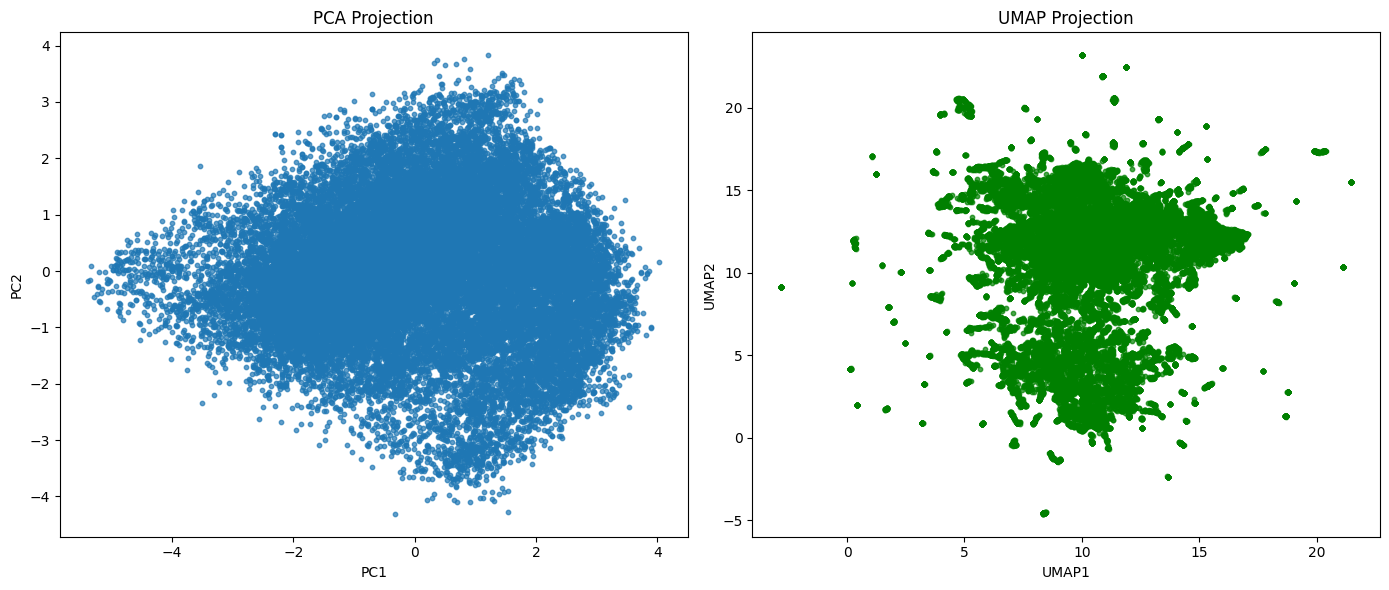

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap.umap_ as umap

# Assume normalized_df is your normalized DataFrame of shape (35137, 468)
# If needed, fill or drop any remaining missing values beforehand.
data = normalized_df.copy()

# ---------------------------
# PCA Dimensionality Reduction
# ---------------------------
# We'll reduce the data to 2 principal components.
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)

# Create a DataFrame for PCA results.
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'], index=data.index)

# ---------------------------
# UMAP Dimensionality Reduction
# ---------------------------
# UMAP parameters can be adjusted; here we reduce the data to 2 components.
umap_reducer = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_reducer.fit_transform(data)

# Create a DataFrame for UMAP results.
umap_df = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'], index=data.index)

# ---------------------------
# Plotting the Results
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot for PCA
axes[0].scatter(pca_df['PC1'], pca_df['PC2'], s=10, alpha=0.7)
axes[0].set_title("PCA Projection")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Scatter plot for UMAP
axes[1].scatter(umap_df['UMAP1'], umap_df['UMAP2'], s=10, alpha=0.7, color='green')
axes[1].set_title("UMAP Projection")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

plt.tight_layout()
plt.show()


## try to do correlation test and see which featrres are corelated with each other to delete the redundunt ones

C:\Users\naman\AppData\Local\Temp\ipykernel_9100\2727387194.py:22: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance_matrix, method='average')


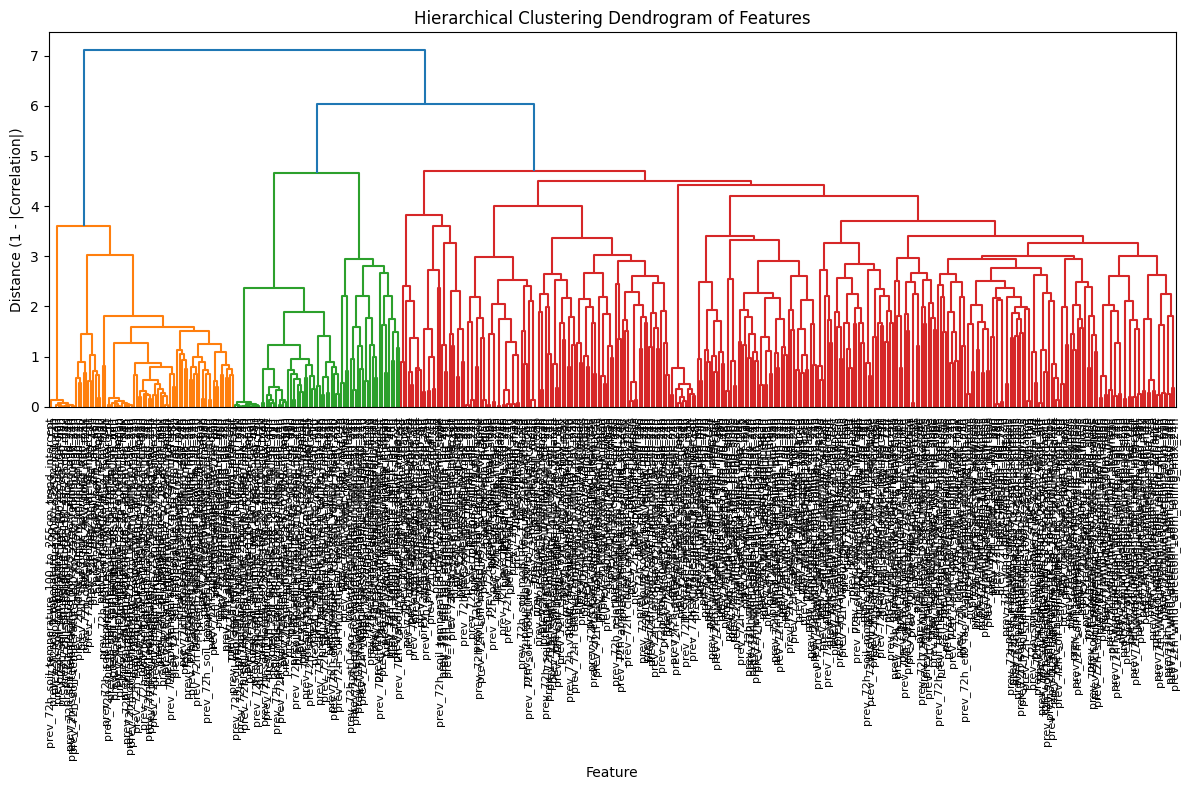

Number of original features: 468
Number of features after dropping highly correlated ones: 143
Dropped features:
['prev_72h_temperature_2m_median', 'prev_72h_temperature_2m_min', 'prev_72h_temperature_2m_max', 'prev_72h_temperature_2m_variance', 'prev_72h_temperature_2m_trend_intercept', 'prev_72h_temperature_2m_lag_24h', 'prev_72h_temperature_2m_lag_48h', 'prev_72h_temperature_2m_lag_72h', 'prev_72h_temperature_2m_rolling_mean_24h', 'prev_72h_temperature_2m_rolling_max_24h', 'prev_72h_temperature_2m_rolling_min_24h', 'prev_72h_temperature_2m_temp_diff', 'prev_72h_relative_humidity_2m_median', 'prev_72h_relative_humidity_2m_min', 'prev_72h_relative_humidity_2m_std', 'prev_72h_relative_humidity_2m_variance', 'prev_72h_relative_humidity_2m_skewness', 'prev_72h_relative_humidity_2m_trend_intercept', 'prev_72h_relative_humidity_2m_rolling_mean_24h', 'prev_72h_relative_humidity_2m_rolling_max_24h', 'prev_72h_relative_humidity_2m_rolling_min_24h', 'prev_72h_relative_humidity_2m_humidity_rang

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

# Assuming final_df is your DataFrame with shape (35137, 468)
# (Make sure it's numeric and handle missing values if needed)
final_df_filled = final_df.fillna(0)

# --------------------------------------
# Part 1: Visualizing Feature Clusters
# --------------------------------------
# Compute absolute correlation matrix
corr_matrix = final_df_filled.corr().abs()

# Compute the distance matrix as (1 - correlation)
# For hierarchical clustering, we need to convert our similarity measure into a distance measure.
distance_matrix = 1 - corr_matrix

# Generate linkage matrix using average linkage method
linkage_matrix = linkage(distance_matrix, method='average')

# Plot dendrogram – note that labels might be overlapped due to a large number of features
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=corr_matrix.columns, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram of Features")
plt.xlabel("Feature")
plt.ylabel("Distance (1 - |Correlation|)")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Part 2: Automatic Feature Elimination by Correlation
# -------------------------------------------------
def drop_highly_correlated_features(df, correlation_threshold=0.95):
    """
    Drops features that are highly correlated. For each pair of features with a correlation
    above the threshold, one feature is removed.
    
    Args:
        df: DataFrame containing the features.
        correlation_threshold: Threshold above which features are considered redundant.
    
    Returns:
        A tuple (df_reduced, dropped_features) where:
         - df_reduced is the DataFrame after dropping features.
         - dropped_features is a list of feature names that were dropped.
    """
    corr_matrix = df.corr().abs()
    # Select the upper triangle of the correlation matrix
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features with a correlation greater than the specified threshold
    drop_cols = [column for column in upper_tri.columns if any(upper_tri[column] > correlation_threshold)]
    
    # Drop these features from the DataFrame
    df_reduced = df.drop(columns=drop_cols)
    return df_reduced, drop_cols

# Apply the function
reduced_df, dropped_features = drop_highly_correlated_features(final_df_filled, correlation_threshold=0.75)

print("Number of original features:", final_df_filled.shape[1])
print("Number of features after dropping highly correlated ones:", reduced_df.shape[1])
print("Dropped features:")
print(dropped_features)


## Try traditional machine learning with this reduced df

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold
# Enable experimental halving search in scikit-learn
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import LinearSVC
# Import classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Optimized Gradient Boosting using LightGBM
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

# -------------------------
# 1. Data Preparation
# -------------------------
# Assume 'reduced_df' is your feature DataFrame and 
# 'merged_df["extreme"]' is your target variable.
X = reduced_df.copy()
y = merged_df["extreme"].values

# Train-test split with stratification (90% training, 10% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

print("Train and test split:")
print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# -------------------------
# 2. Define Cross-validation and Models
# -------------------------
# Use 3-fold CV to speed up tuning
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Define models and their hyperparameter grids, including an optimized LightGBM-based Gradient Boosting.
from sklearn.svm import LinearSVC

# Define models and their hyperparameter grids
models = {
    'Logistic Regression': {
        'model': LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'params': {
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42),
        'params': {
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10]
        }
    },
    'Optimized Gradient Boosting': {
        'model': lgb.LGBMClassifier(class_weight='balanced', random_state=42),
        'params': {
            'num_leaves': [31, 50],
            'learning_rate': [0.05, 0.1],
            'n_estimators': [100, 200]
        }
    },
    'Support Vector Machine': {
        'model': LinearSVC(class_weight='balanced', random_state=42, max_iter=10000),
        'params': {
            'C': [0.1, 1, 10],
            'penalty': ['l2'],
            'loss': ['hinge']
        }
    }
}


results = {}

# -------------------------
# 3. Subsample Training Data for Fast Tuning
# -------------------------
# Use a subset (e.g., 30%) of the training data for hyperparameter tuning
# Define the sample fraction
sample_fraction = 0.3
X_train_reset = X_train.reset_index(drop=True)
# Sample indices
sample_indices = X_train_reset.sample(frac=sample_fraction, random_state=42).index

# Create the sampled datasets
X_train_sample = X_train_reset.loc[sample_indices]
y_train_sample = y_train[sample_indices]

print("\nStarting model training and hyperparameter tuning with HalvingRandomSearchCV:")

# -------------------------
# 4. Model Training with HalvingRandomSearchCV
# -------------------------
for model_name, config in tqdm(models.items(), desc="Models", total=len(models)):
    print(f"\n----- Training {model_name} -----")
    
    # Use HalvingRandomSearchCV for efficient hyperparameter tuning
    halving_search = HalvingRandomSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        scoring='roc_auc',  # Using ROC-AUC for imbalanced data.
        cv=cv_strategy,
        n_jobs=-1,
        verbose=1,
        factor=2,          # Controls the aggressive down-selection
        max_resources='auto'
    )
    
    # Fit on the subsampled training data
    halving_search.fit(X_train_sample, y_train_sample)
    best_model = halving_search.best_estimator_
    
    print(f"Best parameters for {model_name}: {halving_search.best_params_}")
    print(f"Best cross validated ROC-AUC for {model_name}: {halving_search.best_score_:.4f}")
    
    # Evaluate on the full test set.
    y_pred = best_model.predict(X_test)
    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None
    
    print(f"\nEvaluation metrics for {model_name} on the test set:")
    print(classification_report(y_test, y_pred, digits=4))
    if auc is not None:
        print(f"Test ROC-AUC: {auc:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    results[model_name] = {
        'best_model': best_model,
        'best_params': halving_search.best_params_,
        'best_cv_score': halving_search.best_score_,
        'classification_report': classification_report(y_test, y_pred, digits=4, output_dict=True),
        'confusion_matrix': cm,
        'test_auc': auc
    }

print("\nAll models have been trained and evaluated with optimizations.")


Train and test split:
Train set shape: (31623, 143)
Test set shape: (3514, 143)

Starting model training and hyperparameter tuning with HalvingRandomSearchCV:


Models:   0%|          | 0/5 [00:00<?, ?it/s]


----- Training Logistic Regression -----
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 10
min_resources_: 12
max_resources_: 9487
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 4
n_resources: 12
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 1
n_candidates: 2
n_resources: 24
Fitting 3 folds for each of 2 candidates, totalling 6 fits
----------
iter: 2
n_candidates: 1
n_resources: 48
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for Logistic Regression: {'penalty': 'l2', 'C': 10}
Best cross validated ROC-AUC for Logistic Regression: 0.4146

Evaluation metrics for Logistic Regression on the test set:
              precision    recall  f1-score   support

           0     0.9319    0.6218    0.7459      3168
           1     0.1443    0.5838    0.2314       346

    accuracy                         0.6181      3514
   macro avg     0.5381    0.6028    0.4887      3514
weighted avg     0

  File "c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 966, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1435, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


[LightGBM] [Info] Number of positive: 942, number of negative: 8545
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009780 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30999
[LightGBM] [Info] Number of data points in the train set: 9487, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Best parameters for Optimized Gradient Boosting: {'num_leaves': 50, 'n_estimators': 200, 'learning_rate': 0.1}
Best cross validated ROC-AUC for Optimized Gradient Boosting: 0.5983

Evaluation metrics for Optimized Gradient Boosting on the test set:
              precision    recall  f1-score   support

           0     0.9186    0.9766    0.9468      3168
           1     0.4932    0.2081    0.2927       346

    accuracy                         0.9010      3514
   macro avg     0.7059    0.5924    0.6197

## Train models without dropping highly correlated features and train these models

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold
# Enable experimental halving search in scikit-learn
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import LinearSVC
# Import classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Optimized Gradient Boosting using LightGBM
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

# -------------------------
# 1. Data Preparation
# -------------------------
# Assume 'reduced_df' is your feature DataFrame and 
# 'merged_df["extreme"]' is your target variable.
X = final_df_filled.copy()
y = merged_df["extreme"].values

# Train-test split with stratification (90% training, 10% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

print("Train and test split:")
print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# -------------------------
# 2. Define Cross-validation and Models
# -------------------------
# Use 3-fold CV to speed up tuning
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Define models and their hyperparameter grids, including an optimized LightGBM-based Gradient Boosting.
from sklearn.svm import LinearSVC

# Define models and their hyperparameter grids
models = {
    'Logistic Regression': {
        'model': LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'params': {
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42),
        'params': {
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10]
        }
    },
    'Optimized Gradient Boosting': {
        'model': lgb.LGBMClassifier(class_weight='balanced', random_state=42),
        'params': {
            'num_leaves': [31, 50],
            'learning_rate': [0.05, 0.1],
            'n_estimators': [100, 200]
        }
    },
    'Support Vector Machine': {
        'model': LinearSVC(class_weight='balanced', random_state=42, max_iter=10000),
        'params': {
            'C': [0.1, 1, 10],
            'penalty': ['l2'],
            'loss': ['hinge']
        }
    }
}


results = {}

# -------------------------
# 3. Subsample Training Data for Fast Tuning
# -------------------------
# Use a subset (e.g., 30%) of the training data for hyperparameter tuning
# Define the sample fraction
sample_fraction = 0.3
X_train_reset = X_train.reset_index(drop=True)
# Sample indices
sample_indices = X_train_reset.sample(frac=sample_fraction, random_state=42).index

# Create the sampled datasets
X_train_sample = X_train_reset.loc[sample_indices]
y_train_sample = y_train[sample_indices]

print("\nStarting model training and hyperparameter tuning with HalvingRandomSearchCV:")

# -------------------------
# 4. Model Training with HalvingRandomSearchCV
# -------------------------
for model_name, config in tqdm(models.items(), desc="Models", total=len(models)):
    print(f"\n----- Training {model_name} -----")
    
    # Use HalvingRandomSearchCV for efficient hyperparameter tuning
    halving_search = HalvingRandomSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        scoring='roc_auc',  # Using ROC-AUC for imbalanced data.
        cv=cv_strategy,
        n_jobs=-1,
        verbose=1,
        factor=2,          # Controls the aggressive down-selection
        max_resources='auto'
    )
    
    # Fit on the subsampled training data
    halving_search.fit(X_train_sample, y_train_sample)
    best_model = halving_search.best_estimator_
    
    print(f"Best parameters for {model_name}: {halving_search.best_params_}")
    print(f"Best cross validated ROC-AUC for {model_name}: {halving_search.best_score_:.4f}")
    
    # Evaluate on the full test set.
    y_pred = best_model.predict(X_test)
    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None
    
    print(f"\nEvaluation metrics for {model_name} on the test set:")
    print(classification_report(y_test, y_pred, digits=4))
    if auc is not None:
        print(f"Test ROC-AUC: {auc:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    results[model_name] = {
        'best_model': best_model,
        'best_params': halving_search.best_params_,
        'best_cv_score': halving_search.best_score_,
        'classification_report': classification_report(y_test, y_pred, digits=4, output_dict=True),
        'confusion_matrix': cm,
        'test_auc': auc
    }

print("\nAll models have been trained and evaluated with optimizations.")


Train and test split:
Train set shape: (31623, 468)
Test set shape: (3514, 468)

Starting model training and hyperparameter tuning with HalvingRandomSearchCV:


Models:   0%|          | 0/5 [00:00<?, ?it/s]


----- Training Logistic Regression -----
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 10
min_resources_: 12
max_resources_: 9487
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 4
n_resources: 12
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 1
n_candidates: 2
n_resources: 24
Fitting 3 folds for each of 2 candidates, totalling 6 fits
----------
iter: 2
n_candidates: 1
n_resources: 48
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for Logistic Regression: {'penalty': 'l2', 'C': 10}
Best cross validated ROC-AUC for Logistic Regression: 0.5800

Evaluation metrics for Logistic Regression on the test set:
              precision    recall  f1-score   support

           0     0.9366    0.6531    0.7696      3168
           1     0.1579    0.5954    0.2495       346

    accuracy                         0.6474      3514
   macro avg     0.5472    0.6242    0.5096      3514
weighted avg     0

## Do PCA and umpa with gihher compoenets to see if it can capture more variance and train these classifcal models

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap.umap_ as umap

# Assume normalized_df is your normalized DataFrame of shape (35137, 468)
# If needed, fill or drop any remaining missing values beforehand.
data = normalized_df.copy()

# ---------------------------
# PCA Dimensionality Reduction
# ---------------------------
# We'll reduce the data to 2 principal components.
pca = PCA(n_components=35)
pca_result = pca.fit_transform(data)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)

# Create a DataFrame for PCA results.
# pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'], index=data.index)



PCA explained variance ratio: [0.24015939 0.131355   0.06399121 0.05511421 0.04109831 0.03020914
 0.02594545 0.02424855 0.02066774 0.01850668 0.01810558 0.01627751
 0.01535598 0.0146023  0.01406102 0.01223857 0.01178198 0.01096422
 0.0100466  0.01000431 0.00930039 0.0092765  0.00850015 0.007807
 0.00710966 0.00690472 0.00637484 0.00618136 0.0059715  0.00581267
 0.00530904 0.00490282 0.00449073 0.0041022  0.00404262]


In [22]:
sum(pca.explained_variance_ratio_)  # Check how much variance is explained by the first 50 components

np.float64(0.8808199647939735)

In [25]:
pca_result.copy()

array([[ 1.79300437,  2.02185798, -0.70906006, ...,  0.02921123,
         0.21283841, -0.58169554],
       [-1.1064561 , -0.46496656,  0.87435232, ...,  0.13122913,
        -0.02269021,  0.0585092 ],
       [-0.05836678,  1.20182911, -0.14108502, ...,  0.0521029 ,
         0.53660105,  0.00986703],
       ...,
       [-0.50680586,  1.13192446, -0.39920252, ..., -0.0289582 ,
         0.10011321,  0.0869607 ],
       [-0.45641506, -0.79313995, -1.11487313, ..., -0.02533561,
        -0.55223111, -0.03191306],
       [-0.91676873, -1.52973017, -0.53017345, ..., -0.13978069,
        -0.77756111,  0.3269071 ]])

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold
# Enable experimental halving search in scikit-learn
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import LinearSVC
# Import classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Optimized Gradient Boosting using LightGBM
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

# -------------------------
# 1. Data Preparation
# -------------------------
# Assume 'reduced_df' is your feature DataFrame and 
# 'merged_df["extreme"]' is your target variable.
X = pca_result.copy()
y = merged_df["extreme"].values

# Train-test split with stratification (90% training, 10% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

print("Train and test split:")
print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# -------------------------
# 2. Define Cross-validation and Models
# -------------------------
# Use 3-fold CV to speed up tuning
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Define models and their hyperparameter grids, including an optimized LightGBM-based Gradient Boosting.
from sklearn.svm import LinearSVC

# Define models and their hyperparameter grids
models = {
    'Logistic Regression': {
        'model': LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'params': {
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42),
        'params': {
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10]
        }
    },
    'Optimized Gradient Boosting': {
        'model': lgb.LGBMClassifier(class_weight='balanced', random_state=42),
        'params': {
            'num_leaves': [31, 50],
            'learning_rate': [0.05, 0.1],
            'n_estimators': [100, 200]
        }
    },
    'Support Vector Machine': {
        'model': LinearSVC(class_weight='balanced', random_state=42, max_iter=10000),
        'params': {
            'C': [0.1, 1, 10],
            'penalty': ['l2'],
            'loss': ['hinge']
        }
    }
}


results = {}


print("\nStarting model training and hyperparameter tuning with HalvingRandomSearchCV:")

# -------------------------
# 4. Model Training with HalvingRandomSearchCV
# -------------------------
for model_name, config in tqdm(models.items(), desc="Models", total=len(models)):
    print(f"\n----- Training {model_name} -----")
    
    # Use HalvingRandomSearchCV for efficient hyperparameter tuning
    halving_search = HalvingRandomSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        scoring='roc_auc',  # Using ROC-AUC for imbalanced data.
        cv=cv_strategy,
        n_jobs=-1,
        verbose=1,
        factor=2,          # Controls the aggressive down-selection
        max_resources='auto'
    )
    
    # Fit on the subsampled training data
    halving_search.fit(X_train, y_train)
    best_model = halving_search.best_estimator_
    
    print(f"Best parameters for {model_name}: {halving_search.best_params_}")
    print(f"Best cross validated ROC-AUC for {model_name}: {halving_search.best_score_:.4f}")
    
    # Evaluate on the full test set.
    y_pred = best_model.predict(X_test)
    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None
    
    print(f"\nEvaluation metrics for {model_name} on the test set:")
    print(classification_report(y_test, y_pred, digits=4))
    if auc is not None:
        print(f"Test ROC-AUC: {auc:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    results[model_name] = {
        'best_model': best_model,
        'best_params': halving_search.best_params_,
        'best_cv_score': halving_search.best_score_,
        'classification_report': classification_report(y_test, y_pred, digits=4, output_dict=True),
        'confusion_matrix': cm,
        'test_auc': auc
    }

print("\nAll models have been trained and evaluated with optimizations.")


Train and test split:
Train set shape: (31623, 35)
Test set shape: (3514, 35)

Starting model training and hyperparameter tuning with HalvingRandomSearchCV:


Models:   0%|          | 0/5 [00:00<?, ?it/s]


----- Training Logistic Regression -----
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 12
min_resources_: 12
max_resources_: 31623
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 4
n_resources: 12
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 1
n_candidates: 2
n_resources: 24
Fitting 3 folds for each of 2 candidates, totalling 6 fits
----------
iter: 2
n_candidates: 1
n_resources: 48
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for Logistic Regression: {'penalty': 'l2', 'C': 10}
Best cross validated ROC-AUC for Logistic Regression: 0.6992

Evaluation metrics for Logistic Regression on the test set:
              precision    recall  f1-score   support

           0     0.9374    0.5859    0.7211      3168
           1     0.1447    0.6416    0.2362       346

    accuracy                         0.5913      3514
   macro avg     0.5410    0.6137    0.4786      3514
weighted avg     

## Do features selection using random forest, selectkbest and l1, l2 regiraliztion to select important features

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

X = final_df_filled.copy()
y = merged_df["extreme"].values

# Train-test split with stratification (90% training, 10% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

selector = SelectFromModel(rf, threshold="mean", max_features=35)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [34]:
from sklearn.feature_selection import SelectKBest, f_classif

# Initialize SelectKBest with ANOVA F-value
selector = SelectKBest(score_func=f_classif, k=35)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get the selected feature indices
selected_indices = selector.get_support(indices=True)
selected_features = data.columns[selected_indices]
print(f"Selected features: {selected_features}")

Selected features: Index(['prev_72h_precipitation_mean', 'prev_72h_precipitation_median',
       'prev_72h_precipitation_std', 'prev_72h_precipitation_rolling_mean_24h',
       'prev_72h_precipitation_total_precip', 'prev_72h_rain_mean',
       'prev_72h_rain_median', 'prev_72h_rain_std',
       'prev_72h_rain_rolling_mean_24h', 'prev_72h_pressure_msl_min',
       'prev_72h_pressure_msl_rolling_mean_24h',
       'prev_72h_pressure_msl_rolling_max_24h',
       'prev_72h_pressure_msl_rolling_min_24h', 'prev_72h_wind_speed_10m_mean',
       'prev_72h_wind_speed_10m_median', 'prev_72h_wind_speed_10m_max',
       'prev_72h_wind_speed_10m_std', 'prev_72h_wind_speed_10m_lag_24h',
       'prev_72h_wind_speed_10m_rolling_mean_24h',
       'prev_72h_wind_speed_10m_rolling_std_24h',
       'prev_72h_wind_speed_10m_rolling_max_24h',
       'prev_72h_wind_speed_100m_mean', 'prev_72h_wind_speed_100m_median',
       'prev_72h_wind_speed_100m_max', 'prev_72h_wind_speed_100m_std',
       'prev_72h_wind

In [35]:
def tain_models(df):

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from tqdm.auto import tqdm
    from sklearn.model_selection import train_test_split, StratifiedKFold
    # Enable experimental halving search in scikit-learn
    from sklearn.experimental import enable_halving_search_cv  # noqa
    from sklearn.model_selection import HalvingRandomSearchCV
    from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
    from sklearn.svm import LinearSVC
    # Import classifiers
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.svm import SVC

    # Optimized Gradient Boosting using LightGBM
    import lightgbm as lgb

    import warnings
    warnings.filterwarnings('ignore')

    # -------------------------
    # 1. Data Preparation
    # -------------------------
    # Assume 'reduced_df' is your feature DataFrame and 
    # 'merged_df["extreme"]' is your target variable.
    X = df.copy()
    y = merged_df["extreme"].values

    # Train-test split with stratification (90% training, 10% testing)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.10, random_state=42, stratify=y
    )

    print("Train and test split:")
    print(f"Train set shape: {X_train.shape}")
    print(f"Test set shape: {X_test.shape}")

    # -------------------------
    # 2. Define Cross-validation and Models
    # -------------------------
    # Use 3-fold CV to speed up tuning
    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Define models and their hyperparameter grids, including an optimized LightGBM-based Gradient Boosting.
    from sklearn.svm import LinearSVC

    # Define models and their hyperparameter grids
    models = {
        'Logistic Regression': {
            'model': LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
            'params': {
                'C': [0.01, 0.1, 1, 10],
                'penalty': ['l2']
            }
        },
        'Decision Tree': {
            'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
            'params': {
                'max_depth': [None, 5, 10, 15],
                'min_samples_split': [2, 5, 10]
            }
        },
        'Random Forest': {
            'model': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42),
            'params': {
                'max_depth': [None, 5, 10, 15],
                'min_samples_split': [2, 5, 10]
            }
        },
        'Optimized Gradient Boosting': {
            'model': lgb.LGBMClassifier(class_weight='balanced', random_state=42),
            'params': {
                'num_leaves': [31, 50],
                'learning_rate': [0.05, 0.1],
                'n_estimators': [100, 200]
            }
        },
        'Support Vector Machine': {
            'model': LinearSVC(class_weight='balanced', random_state=42, max_iter=10000),
            'params': {
                'C': [0.1, 1, 10],
                'penalty': ['l2'],
                'loss': ['hinge']
            }
        }
    }


    results = {}


    print("\nStarting model training and hyperparameter tuning with HalvingRandomSearchCV:")

    # -------------------------
    # 4. Model Training with HalvingRandomSearchCV
    # -------------------------
    for model_name, config in tqdm(models.items(), desc="Models", total=len(models)):
        print(f"\n----- Training {model_name} -----")
        
        # Use HalvingRandomSearchCV for efficient hyperparameter tuning
        halving_search = HalvingRandomSearchCV(
            estimator=config['model'],
            param_distributions=config['params'],
            scoring='roc_auc',  # Using ROC-AUC for imbalanced data.
            cv=cv_strategy,
            n_jobs=-1,
            verbose=1,
            factor=2,          # Controls the aggressive down-selection
            max_resources='auto'
        )
        
        # Fit on the subsampled training data
        halving_search.fit(X_train, y_train)
        best_model = halving_search.best_estimator_
        
        print(f"Best parameters for {model_name}: {halving_search.best_params_}")
        print(f"Best cross validated ROC-AUC for {model_name}: {halving_search.best_score_:.4f}")
        
        # Evaluate on the full test set.
        y_pred = best_model.predict(X_test)
        if hasattr(best_model, "predict_proba"):
            y_proba = best_model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_proba)
        else:
            auc = None
        
        print(f"\nEvaluation metrics for {model_name} on the test set:")
        print(classification_report(y_test, y_pred, digits=4))
        if auc is not None:
            print(f"Test ROC-AUC: {auc:.4f}")
        
        cm = confusion_matrix(y_test, y_pred)
        print("Confusion Matrix:")
        print(cm)
        
        results[model_name] = {
            'best_model': best_model,
            'best_params': halving_search.best_params_,
            'best_cv_score': halving_search.best_score_,
            'classification_report': classification_report(y_test, y_pred, digits=4, output_dict=True),
            'confusion_matrix': cm,
            'test_auc': auc
        }

    print("\nAll models have been trained and evaluated with optimizations.")
    return results
selectd_features_result_1 = tain_models(final_df_filled[selected_features])

Train and test split:
Train set shape: (31623, 35)
Test set shape: (3514, 35)

Starting model training and hyperparameter tuning with HalvingRandomSearchCV:


Models:   0%|          | 0/5 [00:00<?, ?it/s]


----- Training Logistic Regression -----
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 12
min_resources_: 12
max_resources_: 31623
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 4
n_resources: 12
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 1
n_candidates: 2
n_resources: 24
Fitting 3 folds for each of 2 candidates, totalling 6 fits
----------
iter: 2
n_candidates: 1
n_resources: 48
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for Logistic Regression: {'penalty': 'l2', 'C': 10}
Best cross validated ROC-AUC for Logistic Regression: 0.5211

Evaluation metrics for Logistic Regression on the test set:
              precision    recall  f1-score   support

           0     0.9234    0.6282    0.7477      3168
           1     0.1332    0.5231    0.2123       346

    accuracy                         0.6178      3514
   macro avg     0.5283    0.5756    0.4800      3514
weighted avg     

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# Initialize Logistic Regression with L1 penalty
model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# Select features based on L1 regularization
selector = SelectFromModel(model, threshold="mean", max_features=35)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Get the selected feature indices
selected_indices = selector.get_support(indices=True)
selected_features = data.columns[selected_indices]
print(f"Selected features: {selected_features}")


Selected features: Index(['prev_72h_relative_humidity_2m_trend_slope',
       'prev_72h_precipitation_std', 'prev_72h_precipitation_trend_intercept',
       'prev_72h_rain_rolling_mean_24h', 'prev_72h_rain_rolling_std_24h',
       'prev_72h_pressure_msl_skewness', 'prev_72h_surface_pressure_skewness',
       'prev_72h_et0_fao_evapotranspiration_median',
       'prev_72h_et0_fao_evapotranspiration_max',
       'prev_72h_et0_fao_evapotranspiration_lag_48h',
       'prev_72h_et0_fao_evapotranspiration_lag_72h',
       'prev_72h_et0_fao_evapotranspiration_rolling_max_24h',
       'prev_72h_et0_fao_evapotranspiration_rolling_min_24h',
       'prev_72h_vapour_pressure_deficit_mean',
       'prev_72h_vapour_pressure_deficit_median',
       'prev_72h_vapour_pressure_deficit_rolling_mean_24h',
       'prev_72h_wind_speed_10m_skewness', 'prev_72h_wind_speed_100m_skewness',
       'prev_72h_wind_gusts_10m_trend_slope',
       'prev_72h_soil_temperature_28_to_100cm_std',
       'prev_72h_soil_temp

In [38]:
selected_features_result_2 = tain_models(final_df_filled[selected_features])

Train and test split:
Train set shape: (31623, 35)
Test set shape: (3514, 35)

Starting model training and hyperparameter tuning with HalvingRandomSearchCV:


Models:   0%|          | 0/5 [00:00<?, ?it/s]


----- Training Logistic Regression -----
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 12
min_resources_: 12
max_resources_: 31623
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 4
n_resources: 12
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 1
n_candidates: 2
n_resources: 24
Fitting 3 folds for each of 2 candidates, totalling 6 fits
----------
iter: 2
n_candidates: 1
n_resources: 48
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for Logistic Regression: {'penalty': 'l2', 'C': 10}
Best cross validated ROC-AUC for Logistic Regression: 0.4209

Evaluation metrics for Logistic Regression on the test set:
              precision    recall  f1-score   support

           0     0.9296    0.5915    0.7230      3168
           1     0.1362    0.5896    0.2213       346

    accuracy                         0.5913      3514
   macro avg     0.5329    0.5906    0.4721      3514
weighted avg     

In [41]:
from sklearn.linear_model import Ridge
from sklearn.feature_selection import SelectFromModel

# Initialize Ridge Regression with L2 penalty
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# Select features based on feature importance
selector = SelectFromModel(model, threshold="mean", max_features=35)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Get the selected feature indices
selected_indices = selector.get_support(indices=True)
selected_features = data.columns[selected_indices]
print(f"Selected features: {selected_features}")


Selected features: Index(['prev_72h_temperature_2m_mean', 'prev_72h_precipitation_min',
       'prev_72h_rain_mean', 'prev_72h_rain_min',
       'prev_72h_rain_rolling_mean_24h',
       'prev_72h_et0_fao_evapotranspiration_mean',
       'prev_72h_et0_fao_evapotranspiration_median',
       'prev_72h_et0_fao_evapotranspiration_min',
       'prev_72h_et0_fao_evapotranspiration_std',
       'prev_72h_et0_fao_evapotranspiration_lag_72h',
       'prev_72h_et0_fao_evapotranspiration_rolling_max_24h',
       'prev_72h_et0_fao_evapotranspiration_rolling_min_24h',
       'prev_72h_vapour_pressure_deficit_mean',
       'prev_72h_soil_temperature_7_to_28cm_mean',
       'prev_72h_soil_temperature_28_to_100cm_std',
       'prev_72h_soil_temperature_28_to_100cm_lag_24h',
       'prev_72h_soil_temperature_28_to_100cm_lag_48h',
       'prev_72h_soil_temperature_28_to_100cm_rolling_std_24h',
       'prev_72h_soil_temperature_28_to_100cm_rolling_max_24h',
       'prev_72h_soil_temperature_100_to_255cm_m

In [42]:
selected_features_result_3 = tain_models(final_df_filled[selected_features])

Train and test split:
Train set shape: (31623, 35)
Test set shape: (3514, 35)

Starting model training and hyperparameter tuning with HalvingRandomSearchCV:


Models:   0%|          | 0/5 [00:00<?, ?it/s]


----- Training Logistic Regression -----
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 12
min_resources_: 12
max_resources_: 31623
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 4
n_resources: 12
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 1
n_candidates: 2
n_resources: 24
Fitting 3 folds for each of 2 candidates, totalling 6 fits
----------
iter: 2
n_candidates: 1
n_resources: 48
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for Logistic Regression: {'penalty': 'l2', 'C': 10}
Best cross validated ROC-AUC for Logistic Regression: nan

Evaluation metrics for Logistic Regression on the test set:
              precision    recall  f1-score   support

           0     0.9286    0.6073    0.7344      3168
           1     0.1373    0.5723    0.2215       346

    accuracy                         0.6039      3514
   macro avg     0.5329    0.5898    0.4779      3514
weighted avg     0.8

#### Do feature selectoin on standadized data

In [43]:
standardized_df.shape

(35137, 468)

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

X = standardized_df.copy()
y = merged_df["extreme"].values

# Train-test split with stratification (90% training, 10% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

selector = SelectFromModel(rf, threshold="mean", max_features=35)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [48]:
X_test_selected.shape

(3514, 35)

In [45]:
from sklearn.feature_selection import SelectKBest, f_classif

# Initialize SelectKBest with ANOVA F-value
selector = SelectKBest(score_func=f_classif, k=35)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get the selected feature indices
selected_indices = selector.get_support(indices=True)
selected_features = data.columns[selected_indices]
print(f"Selected features: {selected_features}")

Selected features: Index(['prev_72h_precipitation_mean', 'prev_72h_precipitation_median',
       'prev_72h_precipitation_std', 'prev_72h_precipitation_rolling_mean_24h',
       'prev_72h_precipitation_total_precip', 'prev_72h_rain_mean',
       'prev_72h_rain_median', 'prev_72h_rain_std',
       'prev_72h_rain_rolling_mean_24h', 'prev_72h_pressure_msl_min',
       'prev_72h_pressure_msl_rolling_mean_24h',
       'prev_72h_pressure_msl_rolling_max_24h',
       'prev_72h_pressure_msl_rolling_min_24h', 'prev_72h_wind_speed_10m_mean',
       'prev_72h_wind_speed_10m_median', 'prev_72h_wind_speed_10m_max',
       'prev_72h_wind_speed_10m_std', 'prev_72h_wind_speed_10m_lag_24h',
       'prev_72h_wind_speed_10m_rolling_mean_24h',
       'prev_72h_wind_speed_10m_rolling_std_24h',
       'prev_72h_wind_speed_10m_rolling_max_24h',
       'prev_72h_wind_speed_100m_mean', 'prev_72h_wind_speed_100m_median',
       'prev_72h_wind_speed_100m_max', 'prev_72h_wind_speed_100m_std',
       'prev_72h_wind

In [46]:
selected_features_standadrized_results = tain_models(standardized_df[selected_features])

Train and test split:
Train set shape: (31623, 35)
Test set shape: (3514, 35)

Starting model training and hyperparameter tuning with HalvingRandomSearchCV:


Models:   0%|          | 0/5 [00:00<?, ?it/s]


----- Training Logistic Regression -----
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 12
min_resources_: 12
max_resources_: 31623
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 4
n_resources: 12
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 1
n_candidates: 2
n_resources: 24
Fitting 3 folds for each of 2 candidates, totalling 6 fits
----------
iter: 2
n_candidates: 1
n_resources: 48
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for Logistic Regression: {'penalty': 'l2', 'C': 10}
Best cross validated ROC-AUC for Logistic Regression: nan

Evaluation metrics for Logistic Regression on the test set:
              precision    recall  f1-score   support

           0     0.9226    0.6285    0.7477      3168
           1     0.1320    0.5173    0.2103       346

    accuracy                         0.6175      3514
   macro avg     0.5273    0.5729    0.4790      3514
weighted avg     0.8

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# Initialize Logistic Regression with L1 penalty
model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# Select features based on L1 regularization
selector = SelectFromModel(model, threshold="mean", max_features=35)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Get the selected feature indices
selected_indices = selector.get_support(indices=True)
selected_features = data.columns[selected_indices]
print(f"Selected features: {selected_features}")


Selected features: Index(['prev_72h_temperature_2m_max', 'prev_72h_temperature_2m_lag_48h',
       'prev_72h_dew_point_2m_mean', 'prev_72h_dew_point_2m_median',
       'prev_72h_dew_point_2m_trend_slope', 'prev_72h_dew_point_2m_lag_72h',
       'prev_72h_apparent_temperature_max',
       'prev_72h_apparent_temperature_trend_slope',
       'prev_72h_apparent_temperature_lag_48h',
       'prev_72h_apparent_temperature_lag_72h',
       'prev_72h_apparent_temperature_rolling_mean_24h',
       'prev_72h_precipitation_std', 'prev_72h_rain_mean',
       'prev_72h_rain_rolling_mean_24h', 'prev_72h_rain_rolling_std_24h',
       'prev_72h_pressure_msl_variance', 'prev_72h_surface_pressure_max',
       'prev_72h_surface_pressure_variance', 'prev_72h_cloud_cover_low_std',
       'prev_72h_cloud_cover_low_variance', 'prev_72h_cloud_cover_high_std',
       'prev_72h_wind_speed_100m_mean', 'prev_72h_wind_speed_100m_max',
       'prev_72h_wind_gusts_10m_mean',
       'prev_72h_wind_gusts_10m_rolling_m

In [52]:
from sklearn.linear_model import Ridge
from sklearn.feature_selection import SelectFromModel

# Initialize Ridge Regression with L2 penalty
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# Select features based on feature importance
selector = SelectFromModel(model, threshold="mean", max_features=35)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Get the selected feature indices
selected_indices = selector.get_support(indices=True)
selected_features = data.columns[selected_indices]
print(f"Selected features: {selected_features}")


Selected features: Index(['prev_72h_temperature_2m_lag_48h',
       'prev_72h_temperature_2m_rolling_mean_24h',
       'prev_72h_apparent_temperature_trend_slope',
       'prev_72h_apparent_temperature_lag_48h',
       'prev_72h_apparent_temperature_lag_72h',
       'prev_72h_precipitation_rolling_mean_24h',
       'prev_72h_precipitation_rolling_max_24h', 'prev_72h_rain_mean',
       'prev_72h_rain_rolling_mean_24h', 'prev_72h_rain_rolling_std_24h',
       'prev_72h_surface_pressure_median', 'prev_72h_surface_pressure_min',
       'prev_72h_surface_pressure_max', 'prev_72h_surface_pressure_lag_24h',
       'prev_72h_surface_pressure_lag_48h',
       'prev_72h_surface_pressure_rolling_mean_24h',
       'prev_72h_soil_temperature_7_to_28cm_mean',
       'prev_72h_soil_temperature_7_to_28cm_median',
       'prev_72h_soil_temperature_7_to_28cm_trend_intercept',
       'prev_72h_soil_temperature_7_to_28cm_rolling_max_24h',
       'prev_72h_soil_temperature_28_to_100cm_min',
       'prev_72

In [53]:
selected_features_standadrized_results_e = tain_models(standardized_df[selected_features])

Train and test split:
Train set shape: (31623, 35)
Test set shape: (3514, 35)

Starting model training and hyperparameter tuning with HalvingRandomSearchCV:


Models:   0%|          | 0/5 [00:00<?, ?it/s]


----- Training Logistic Regression -----
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 12
min_resources_: 12
max_resources_: 31623
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 4
n_resources: 12
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 1
n_candidates: 2
n_resources: 24
Fitting 3 folds for each of 2 candidates, totalling 6 fits
----------
iter: 2
n_candidates: 1
n_resources: 48
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for Logistic Regression: {'penalty': 'l2', 'C': 10}
Best cross validated ROC-AUC for Logistic Regression: nan

Evaluation metrics for Logistic Regression on the test set:
              precision    recall  f1-score   support

           0     0.9309    0.6212    0.7452      3168
           1     0.1429    0.5780    0.2291       346

    accuracy                         0.6170      3514
   macro avg     0.5369    0.5996    0.4871      3514
weighted avg     0.8

## Try wihtout engineered features, just scaled raw data

In [5]:
# Train-test split with stratification (90% training, 10% testing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    merged_df[meteo_cols], merged_df["extreme"].values, test_size=0.10, random_state=42, stratify=merged_df["extreme"].values
)

In [6]:
data_3d_X_train = np.stack(X_train.values.tolist(), axis=0)
data_3d_X_test = np.stack(X_test.values.tolist(), axis=0)

In [7]:
data_3d_X_train.shape

(31623, 27, 72)

In [8]:
data_3d_X_train = data_3d_X_train[:,:,-12:]

In [10]:
data_3d_X_test = data_3d_X_test[:,:,-12:]

In [9]:
data_3d_X_train.shape

(31623, 27, 12)

In [11]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Reshape for scaling: (35000 * 27, 72)
reshaped_data_X_train = data_3d_X_train.reshape(-1, data_3d_X_train.shape[-1])
reshaped_data_X_test = data_3d_X_test.reshape(-1, data_3d_X_test.shape[-1])
# Fit and transform
standardized_data_X_train = scaler.fit_transform(reshaped_data_X_train)
standardized_data_X_test = scaler.transform(reshaped_data_X_test)

# Reshape back to (35000, 27, 72)
standardized_data_3d_train = standardized_data_X_train.reshape(data_3d_X_train.shape)
standardized_data_3d_test = standardized_data_X_test.reshape(data_3d_X_test.shape)

In [12]:
standardized_data_3d_train.shape

(31623, 27, 12)

In [71]:
def train_models_original(X_train, y_train, X_test, y_test):

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from tqdm.auto import tqdm
    from sklearn.model_selection import train_test_split, StratifiedKFold
    # Enable experimental halving search in scikit-learn
    from sklearn.experimental import enable_halving_search_cv  # noqa
    from sklearn.model_selection import HalvingRandomSearchCV
    from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
    from sklearn.svm import LinearSVC
    # Import classifiers
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.svm import SVC

    # Optimized Gradient Boosting using LightGBM
    import lightgbm as lgb

    import warnings
    warnings.filterwarnings('ignore')

    # -------------------------
    # 1. Data Preparation
    # -------------------------
    # Assume 'reduced_df' is your feature DataFrame and 
    # 'merged_df["extreme"]' is your target variable.



    print("Train and test split:")
    print(f"Train set shape: {X_train.shape}")
    print(f"Test set shape: {X_test.shape}")

    # -------------------------
    # 2. Define Cross-validation and Models
    # -------------------------
    # Use 3-fold CV to speed up tuning
    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Define models and their hyperparameter grids, including an optimized LightGBM-based Gradient Boosting.
    from sklearn.svm import LinearSVC

    # Define models and their hyperparameter grids
    models = {
        'Logistic Regression': {
            'model': LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
            'params': {
                'C': [0.01, 0.1, 1, 10],
                'penalty': ['l2']
            }
        },
        'Decision Tree': {
            'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
            'params': {
                'max_depth': [None, 5, 10, 15],
                'min_samples_split': [2, 5, 10]
            }
        },
        'Random Forest': {
            'model': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42),
            'params': {
                'max_depth': [None, 5, 10, 15],
                'min_samples_split': [2, 5, 10]
            }
        },
        'Optimized Gradient Boosting': {
            'model': lgb.LGBMClassifier(class_weight='balanced', random_state=42),
            'params': {
                'num_leaves': [31, 50],
                'learning_rate': [0.05, 0.1],
                'n_estimators': [100, 200]
            }
        },
        'Support Vector Machine': {
            'model': LinearSVC(class_weight='balanced', random_state=42, max_iter=10000),
            'params': {
                'C': [0.1, 1, 10],
                'penalty': ['l2'],
                'loss': ['hinge']
            }
        }
    }


    results = {}


    print("\nStarting model training and hyperparameter tuning with HalvingRandomSearchCV:")

    # -------------------------
    # 4. Model Training with HalvingRandomSearchCV
    # -------------------------
    for model_name, config in tqdm(models.items(), desc="Models", total=len(models)):
        print(f"\n----- Training {model_name} -----")
        
        # Use HalvingRandomSearchCV for efficient hyperparameter tuning
        halving_search = HalvingRandomSearchCV(
            estimator=config['model'],
            param_distributions=config['params'],
            scoring='roc_auc',  # Using ROC-AUC for imbalanced data.
            cv=cv_strategy,
            n_jobs=-1,
            verbose=1,
            factor=2,          # Controls the aggressive down-selection
            max_resources='auto'
        )
        
        # Fit on the subsampled training data
        halving_search.fit(X_train, y_train)
        best_model = halving_search.best_estimator_
        
        print(f"Best parameters for {model_name}: {halving_search.best_params_}")
        print(f"Best cross validated ROC-AUC for {model_name}: {halving_search.best_score_:.4f}")
        
        # Evaluate on the full test set.
        y_pred = best_model.predict(X_test)
        if hasattr(best_model, "predict_proba"):
            y_proba = best_model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_proba)
        else:
            auc = None
        
        print(f"\nEvaluation metrics for {model_name} on the test set:")
        print(classification_report(y_test, y_pred, digits=4))
        if auc is not None:
            print(f"Test ROC-AUC: {auc:.4f}")
        
        cm = confusion_matrix(y_test, y_pred)
        print("Confusion Matrix:")
        print(cm)
        
        results[model_name] = {
            'best_model': best_model,
            'best_params': halving_search.best_params_,
            'best_cv_score': halving_search.best_score_,
            'classification_report': classification_report(y_test, y_pred, digits=4, output_dict=True),
            'confusion_matrix': cm,
            'test_auc': auc
        }

    print("\nAll models have been trained and evaluated with optimizations.")
    return results


In [81]:
standardized_data_3d_train_flattened = standardized_data_3d_train.reshape(standardized_data_3d_train.shape[0], -1)
standardized_data_3d_test_flattened = standardized_data_3d_test.reshape(standardized_data_3d_test.shape[0], -1)


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap.umap_ as umap

# Assume normalized_df is your normalized DataFrame of shape (35137, 468)
# If needed, fill or drop any remaining missing values beforehand.

# ---------------------------
# PCA Dimensionality Reduction
# ---------------------------
# We'll reduce the data to 2 principal components.
pca = PCA(n_components=100)
pca_result_train = pca.fit_transform(standardized_data_3d_train_flattened)
pca_result_test = pca.transform(standardized_data_3d_test_flattened)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained: ", sum(pca.explained_variance_ratio_))


PCA explained variance ratio: [0.19273793 0.09104792 0.07506203 0.05883739 0.05570664 0.03537968
 0.02525574 0.02294829 0.02176994 0.02002918 0.01865142 0.0136067
 0.01264251 0.01067945 0.01009129 0.00915142 0.00849937 0.00834395
 0.00749269 0.00742402 0.00710691 0.00654453 0.00600249 0.0058873
 0.00534935 0.00529667 0.00519434 0.00475858 0.00467159 0.00433255
 0.00414478 0.00402206 0.00399155 0.00390362 0.00370635 0.00353293
 0.00350777 0.00334112 0.00316733 0.00313597 0.00306413 0.00290798
 0.00288124 0.00280669 0.00274204 0.00269173 0.00261531 0.00253427
 0.00242926 0.00235835 0.00225994 0.00214975 0.00214375 0.00212585
 0.00204268 0.00202665 0.00197847 0.00196414 0.00191941 0.00186924
 0.00181284 0.00177184 0.00176276 0.00175499 0.00170053 0.00166927
 0.00163391 0.00159167 0.00153472 0.00152893 0.00149756 0.00147684
 0.00145605 0.00143376 0.00137985 0.00136952 0.00134984 0.00133342
 0.00130035 0.00128615 0.00127155 0.00126583 0.00125977 0.00125246
 0.00124366 0.00122785 0.00120986 

In [82]:

results_original = train_models_original(pca_result_train, y_train, pca_result_test, y_test)

Train and test split:
Train set shape: (31623, 100)
Test set shape: (3514, 100)

Starting model training and hyperparameter tuning with HalvingRandomSearchCV:


Models:   0%|          | 0/5 [00:00<?, ?it/s]


----- Training Logistic Regression -----
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 12
min_resources_: 12
max_resources_: 31623
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 4
n_resources: 12
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 1
n_candidates: 2
n_resources: 24
Fitting 3 folds for each of 2 candidates, totalling 6 fits
----------
iter: 2
n_candidates: 1
n_resources: 48
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for Logistic Regression: {'penalty': 'l2', 'C': 10}
Best cross validated ROC-AUC for Logistic Regression: 0.5071

Evaluation metrics for Logistic Regression on the test set:
              precision    recall  f1-score   support

           0     0.9338    0.5836    0.7183      3168
           1     0.1402    0.6214    0.2287       346

    accuracy                         0.5874      3514
   macro avg     0.5370    0.6025    0.4735      3514
weighted avg     

ValueError: 
All the 9 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_classes.py", line 321, in fit
    self.coef_, self.intercept_, n_iter_ = _fit_liblinear(
  File "c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_b

## Do undersampling, oversampling, smote, Adaysn and train these models

In [103]:
%pip install smote-variants==1.0.1



Note: you may need to restart the kernel to use updated packages.


In [ ]:
.shape

(31623, 27, 72)

In [104]:
import smote_variants
print(smote_variants.__version__)

1.0.1


In [ ]:
from smote_variants import SMOTE_IPF, G_SMOTE, SMOTE_ENN

# Reshape to 2D (samples, features*timesteps)
X_2d = standardized_data_3d_train.reshape(-1, 27*72)

# 1. SMOTE_IPF (Imitates physical weather patterns)
# oversampler_ipf = SMOTE_IPF(
#     n_components=35,
#     n_neighbors=12,  # Matches 72h temporal window (12h × 6)
#     proportion=1.0,  # 100% of the minority class

# )
# X_res_ipf, y_res_ipf = oversampler_ipf.sample(X_2d, y_train)

# # 2. G-SMOTE (Geometric SMOTE for multivariate series)
# oversampler_g = G_SMOTE(
#     n_neighbors=6,    # 6-hour temporal blocks
#     deformation_factor=0.5
# )
# X_res_g, y_res_g = oversampler_ipf.sample(X_2d, y_train)
import time
from tqdm import tqdm

class ProgressSMOTE(SMOTE_IPF):
    def _sample(self, X, y):
        with tqdm(total=len(X)) as pbar:
            for _ in super()._sample(X, y):
                pbar.update(1)
                yield

oversampler = ProgressSMOTE()
X_res, y_res = oversampler.sample(X_2d, y_train)



2025-04-09 11:37:10,994:INFO:ProgressSMOTE: Running sampling via ('ProgressSMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'ss_params': {'n_dim': 2, 'simplex_sampling': 'random', 'within_simplex_sampling': 'random', 'gaussian_component': None}, 'n_folds': 9, 'k': 3, 'p': 0.01, 'voting': 'majority', 'n_jobs': 1, 'classifier': ('sklearn.tree', 'DecisionTreeClassifier', {'random_state': 2}), 'random_state': None, 'class_name': 'ProgressSMOTE'}")
2025-04-09 11:37:10,997:INFO:SMOTE: Running sampling via ('SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'ss_params': {'n_dim': 2, 'simplex_sampling': 'random', 'within_simplex_sampling': 'random', 'gaussian_component': {}}, 'random_state': None, 'class_name': 'SMOTE'}")
2025-04-09 11:37:11,036:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2025-04-09 11:37:11,045:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
c:\Users\naman\AppData\Local\Programs\Python\Pyt

In [10]:
standardized_data_3d_train.shape

(31623, 27, 72)

In [13]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import random
import math
from tqdm import tqdm # Import tqdm

# Assuming tSmote.py is in the same directory or accessible in your Python path
# We won't directly use most functions, but will adapt the SMOTE logic.
# import tSmote as ts # We'll extract the core logic instead

# --- Configuration ---
RANDOM_SEED = 42
N_NEIGHBORS = 5 # K value for SMOTE, ensure N_NEIGHBORS < number of minority samples

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# --- Load Your Data ---
# This is a placeholder. Replace with your actual data loading.
# Example: df = pd.read_csv('your_weather_data.csv')
#          weather_data = ... # extract the (35000, 27, 72) numpy array
#          labels = df['extreme'].values # extract the (35000,) labels array

# For demonstration, let's create dummy data with the specified shape
print("Creating dummy data...")
# Use a smaller sample size for quick testing, increase for your real data
n_samples = 31623 # Use 35000 for your actual data
n_features = 27
n_timesteps = 72

# Simulate imbalanced data (e.g., 10% minority class)
minority_fraction = 0.1
n_minority = int(n_samples * minority_fraction)
n_majority = n_samples - n_minority

weather_data = standardized_data_3d_train
labels = y_train
np.random.shuffle(labels) # Shuffle labels to mix classes

print(f"Dummy data shape: {weather_data.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Minority samples: {n_minority}, Majority samples: {n_majority}")
print("-" * 30)

# --- Separate Data by Class ---
minority_data = weather_data[labels == 1]
majority_data = weather_data[labels == 0]

n_min_samples = minority_data.shape[0]

if n_min_samples <= N_NEIGHBORS:
    raise ValueError(f"Number of minority samples ({n_min_samples}) must be greater than N_NEIGHBORS ({N_NEIGHBORS}) for SMOTE.")

# --- Calculate Number of Synthetic Samples Needed ---
n_synthetic_needed = n_majority - n_min_samples
if n_synthetic_needed <= 0:
    print("Minority class is already balanced or larger. No oversampling needed.")
    synthetic_data_final = np.zeros((0, n_features, n_timesteps)) # Create empty array if no synth needed
else:
    print(f"Need to generate {n_synthetic_needed} synthetic minority samples.")

print("-" * 30)

# --- SMOTE Logic (Adapted, Vector-wise per time step) ---

def smote_time_step(data_at_t, n_to_generate, k_neighbors):
    """
    Applies SMOTE to the data slice corresponding to a single time step.

    Args:
        data_at_t (np.ndarray): Data for minority class at a specific time step (shape: n_minority_samples, n_features).
        n_to_generate (int): Number of synthetic samples to generate for this time step.
        k_neighbors (int): Number of nearest neighbors for SMOTE.

    Returns:
        np.ndarray: Array of synthetic samples for this time step (shape: n_to_generate, n_features).
    """
    n_minority_samples, n_features = data_at_t.shape
    synthetic_samples = np.zeros((n_to_generate, n_features))

    if n_minority_samples <= k_neighbors:
        # Handle edge case: not enough samples for specified k
        # Option 1: Reduce k
        k_neighbors = n_minority_samples - 1
        if k_neighbors <= 0:
             # Just duplicate the single sample if k becomes 0 or less
             indices = np.random.choice(n_minority_samples, n_to_generate, replace=True)
             return data_at_t[indices]

    nn = NearestNeighbors(n_neighbors=k_neighbors + 1).fit(data_at_t) # Fit with k+1 to include self

    for i in range(n_to_generate):
        # 1. Choose a random minority sample
        idx = random.randint(0, n_minority_samples - 1)
        sample = data_at_t[idx]

        # 2. Find its k nearest neighbors
        distances, indices = nn.kneighbors(sample.reshape(1, -1))
        # indices[0][0] is the sample itself, neighbors are indices[0][1:]
        neighbor_indices = indices[0][1:k_neighbors+1] # Select exactly k neighbors

        if not len(neighbor_indices): # Should only happen if k became 0
             synthetic_samples[i] = sample # Just duplicate if no neighbours left
             continue

        # 3. Choose one neighbor randomly
        chosen_neighbor_idx = random.choice(neighbor_indices)
        neighbor = data_at_t[chosen_neighbor_idx]

        # 4. Generate synthetic sample
        gap = random.random()
        synthetic_samples[i] = sample + gap * (neighbor - sample)

    return synthetic_samples

# --- Generate Synthetic Data Time Step by Time Step ---
if n_synthetic_needed > 0: # Only run if we need synthetic samples
    print("Generating synthetic data using adapted tSMOTE (vector-wise per time step)...")
    all_synthetic_data_t = [] # List to hold synthetic data for each timestep

    # Wrap range(n_timesteps) with tqdm for progress bar
    for t in tqdm(range(n_timesteps), desc="Generating Synthetic Data (Time Steps)"):
        data_slice_at_t = minority_data[:, :, t] # Shape: (n_min_samples, n_features)

        # Generate n_synthetic_needed at *each* step to create n_synthetic_needed new series
        if n_min_samples > 1 : # Need at least 2 samples for SMOTE
           synthetic_slice = smote_time_step(data_slice_at_t, n_synthetic_needed, N_NEIGHBORS)
        else: # Handle case with 0 or 1 minority sample at this step
           if n_min_samples == 1:
               synthetic_slice = np.tile(data_slice_at_t, (n_synthetic_needed, 1))
           else:
               synthetic_slice = np.zeros((n_synthetic_needed, n_features)) # Or handle differently
               # Add a warning if desired, but might be too noisy in a loop
               # print(f"Warning: 0 minority samples at timestep {t}. Generating zeros.")

        all_synthetic_data_t.append(synthetic_slice) # List of arrays [ (N_synth, feats), (N_synth, feats), ...]

    print("Synthetic data generation complete.")
    print("-" * 30)

    # --- Reassemble Synthetic Data ---
    print("Reassembling synthetic data...")
    synthetic_data_final = np.zeros((n_synthetic_needed, n_features, n_timesteps))

    for t in range(n_timesteps):
        synthetic_data_final[:, :, t] = all_synthetic_data_t[t]

    print(f"Shape of final synthetic data: {synthetic_data_final.shape}")
    print("-" * 30)

else: # Case where no synthetic samples were needed
    synthetic_data_final = np.zeros((0, n_features, n_timesteps))


# --- Combine Original Minority and Synthetic Data ---
oversampled_minority_data = np.concatenate((minority_data, synthetic_data_final), axis=0)
oversampled_minority_labels = np.ones(oversampled_minority_data.shape[0], dtype=int)

print(f"Shape of oversampled minority data: {oversampled_minority_data.shape}")

# --- (Optional) Combine with Majority Data ---
final_weather_data = np.concatenate((majority_data, oversampled_minority_data), axis=0)
final_labels = np.concatenate((labels[labels == 0], oversampled_minority_labels), axis=0)

# Optionally shuffle the final combined dataset
shuffle_indices = np.random.permutation(len(final_labels))
final_weather_data = final_weather_data[shuffle_indices]
final_labels = final_labels[shuffle_indices]


print(f"Shape of final balanced data: {final_weather_data.shape}")
print(f"Shape of final balanced labels: {final_labels.shape}")
print(f"Final class distribution: {np.bincount(final_labels)}")

# --- Now you can use 'final_weather_data' and 'final_labels' for your model training ---

Creating dummy data...
Dummy data shape: (31623, 27, 72)
Labels shape: (31623,)
Minority samples: 3162, Majority samples: 28461
------------------------------
Need to generate 25348 synthetic minority samples.
------------------------------
Generating synthetic data using adapted tSMOTE (vector-wise per time step)...


Generating Synthetic Data (Time Steps): 100%|██████████| 72/72 [25:49<00:00, 21.53s/it]


Synthetic data generation complete.
------------------------------
Reassembling synthetic data...
Shape of final synthetic data: (25348, 27, 72)
------------------------------
Shape of oversampled minority data: (28461, 27, 72)
Shape of final balanced data: (56971, 27, 72)
Shape of final balanced labels: (56971,)
Final class distribution: [28510 28461]


In [ ]:
## most efficiently save the variables
standardized_data_3d_train.shape

(7782, 27, 72)

In [20]:
sum(y_train)/len(y_train), sum(y_test)/len(y_test)

(np.float64(0.40002570033410434), np.float64(0.4))

In [ ]:
import numpy as np
import pandas as pd
import importlib
# from sklearn.neighbors import NearestNeighbors # No longer needed directly here
import random
# import math # Not directly needed here
from tqdm import tqdm # For progress bar

# --- IMPORTANT: Make sure tSmote.py is in the same directory ---
# --- or that its path is added to your Python environment ---
try:
    import tSmote as ts
    print("Successfully imported tSmote.py")
except ImportError:
    print("ERROR: Could not import tSmote.py. Make sure it's in the correct directory or Python path.")
    exit()
importlib.reload(ts)
# --- Configuration ---
RANDOM_SEED = 42
N_NEIGHBORS = 5 # K value for SMOTE, ensure N_NEIGHBORS < number of minority samples

# Seed setting - tSmote.py already sets np.random.seed(0) internally
# We might want to control the standard random module seed as well.
random.seed(RANDOM_SEED)
# Note: ts.generateTimePoints uses np.random internally, which is seeded to 0 in tSmote.py
# If you need different seeding for numpy within ts.generateTimePoints, you'd modify tSmote.py
# or re-seed numpy *just before* calling it, knowing it might affect reproducibility if
# other parts of your code rely on numpy's random state. For simplicity, we'll rely
# on the internal seed(0) for now, but be aware of this.
# np.random.seed(RANDOM_SEED) # Overridden by tSmote.py if imported after

# --- Load Your Data ---
# Placeholder - Replace with your actual data loading
print("Creating dummy data...")
n_samples = 7782 # Use 35000 for your actual data
n_features = 27
n_timesteps = 72

minority_fraction = sum(y_train)/len(y_train)
n_minority = int(n_samples * minority_fraction)
n_majority = n_samples - n_minority

weather_data = standardized_data_3d_train.shape[0]
labels = y_train
np.random.shuffle(labels)

print(f"Dummy data shape: {weather_data.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Minority samples: {n_minority}, Majority samples: {n_majority}")
print("-" * 30)

# --- Separate Data by Class ---
minority_data = weather_data[labels == 1]
majority_data = weather_data[labels == 0]

n_min_samples = minority_data.shape[0]

if n_min_samples <= N_NEIGHBORS:
    # generateTimePoints might handle this by reducing k, but let's check upfront
    print(f"Warning: Number of minority samples ({n_min_samples}) is less than or equal to N_NEIGHBORS ({N_NEIGHBORS}). SMOTE behavior might be affected (k might be reduced internally).")
    if n_min_samples <= 1:
         raise ValueError(f"Cannot perform SMOTE with {n_min_samples} minority sample(s). Need at least 2.")


# --- Calculate Number of Synthetic Samples Needed ---
n_synthetic_needed = n_majority - n_min_samples
if n_synthetic_needed <= 0:
    print("Minority class is already balanced or larger. No oversampling needed.")
    synthetic_data_final = np.zeros((0, n_features, n_timesteps)) # Empty array
else:
    print(f"Need to generate {n_synthetic_needed} synthetic minority samples.")

print("-" * 30)


# --- Prepare Input Data Structure for generateTimePoints ---
# We need a list of lists, where each inner list contains the feature vectors
# for all minority samples at a specific time step.
minority_time_slices = []
print("Structuring minority data into time slices...")
for t in tqdm(range(n_timesteps), desc="Preparing Time Slices"):
    # Extract data for time step t: shape (n_minority_samples, n_features)
    data_slice_at_t = minority_data[:, :, t]
    # Convert to list of lists (as expected by generateTimePoints)
    minority_time_slices.append(data_slice_at_t.tolist())

print(f"Created {len(minority_time_slices)} time slices for minority data.")
print("-" * 30)


# --- Generate Synthetic Data using tSmote.generateTimePoints ---
if n_synthetic_needed > 0:
    print(f"Generating {n_synthetic_needed} synthetic samples per time step using ts.generateTimePoints...")
    # nPoints parameter is the number of synthetic samples PER time slice.
    # Since we want n_synthetic_needed *new series*, we generate this many per slice.
    # Note: generateTimePoints doesn't have a built-in progress bar for its internal loops.
    tSliceSyn = ts.generateTimePoints(minority_time_slices, nPoints=n_synthetic_needed, nNeighbors=N_NEIGHBORS)
    print("Synthetic data generation complete (using tSmote.py function).")
    print("-" * 30)

    # --- Reassemble Synthetic Data ---
    # Output tSliceSyn is List[List[List[float]]], specifically List_timeslice[List_synthetic_sample[List_features]]
    # Shape of tSliceSyn[t] is (n_synthetic_needed, n_features)
    print("Reassembling synthetic data...")
    synthetic_data_final = np.zeros((n_synthetic_needed, n_features, n_timesteps))

    for t in tqdm(range(n_timesteps), desc="Reassembling Data"):
        # Convert the inner list of lists to a numpy array and assign
        synthetic_data_final[:, :, t] = np.array(tSliceSyn[t])

    print(f"Shape of final synthetic data: {synthetic_data_final.shape}")
    print("-" * 30)

else: # Case where no synthetic samples were needed
    synthetic_data_final = np.zeros((0, n_features, n_timesteps))

# --- Combine Original Minority and Synthetic Data ---
oversampled_minority_data = np.concatenate((minority_data, synthetic_data_final), axis=0)
oversampled_minority_labels = np.ones(oversampled_minority_data.shape[0], dtype=int)

print(f"Shape of oversampled minority data: {oversampled_minority_data.shape}")

# --- (Optional) Combine with Majority Data ---
final_weather_data = np.concatenate((majority_data, oversampled_minority_data), axis=0)
final_labels = np.concatenate((labels[labels == 0], oversampled_minority_labels), axis=0)

# Optionally shuffle the final combined dataset
shuffle_indices = np.random.permutation(len(final_labels))
final_weather_data_2 = final_weather_data[shuffle_indices]
final_labels_2 = final_labels[shuffle_indices]

print(f"Shape of final balanced data: {final_weather_data_2.shape}")
print(f"Shape of final balanced labels: {final_labels_2.shape}")
print(f"Final class distribution: {np.bincount(final_labels_2)}")

# --- Now you can use 'final_weather_data' and 'final_labels' for your model training ---

Successfully imported tSmote.py
Creating dummy data...
Dummy data shape: (7782, 27, 72)
Labels shape: (7782,)
Minority samples: 3112, Majority samples: 4670
------------------------------
Need to generate 100 synthetic minority samples.
------------------------------
Structuring minority data into time slices...


Preparing Time Slices: 100%|██████████| 72/72 [00:00<00:00, 139.94it/s]


Created 72 time slices for minority data.
------------------------------
Generating 100 synthetic samples per time step using ts.generateTimePoints...
Using 12 worker processes.
Processing time slices in parallel...


Generating Synthetic Points: 100%|██████████| 72/72 [00:24<00:00,  2.94it/s]


Parallel processing complete.
Synthetic data generation complete (using tSmote.py function).
------------------------------
Reassembling synthetic data...


Reassembling Data: 100%|██████████| 72/72 [00:00<00:00, 7188.69it/s]

Shape of final synthetic data: (100, 27, 72)
------------------------------
Shape of oversampled minority data: (3213, 27, 72)
Shape of final balanced data: (7882, 27, 72)
Shape of final balanced labels: (7882,)
Final class distribution: [4669 3213]


In [34]:
merged_df["event_type"].value_counts()

event_type
Flash Flood           14733
Flood                 13440
Heavy Rain             6576
Debris Flow             191
Thunderstorm Wind        63
Marine High Wind         61
Lightning                30
Marine Strong Wind       21
Hail                     20
Funnel Cloud              2
Name: count, dtype: int64

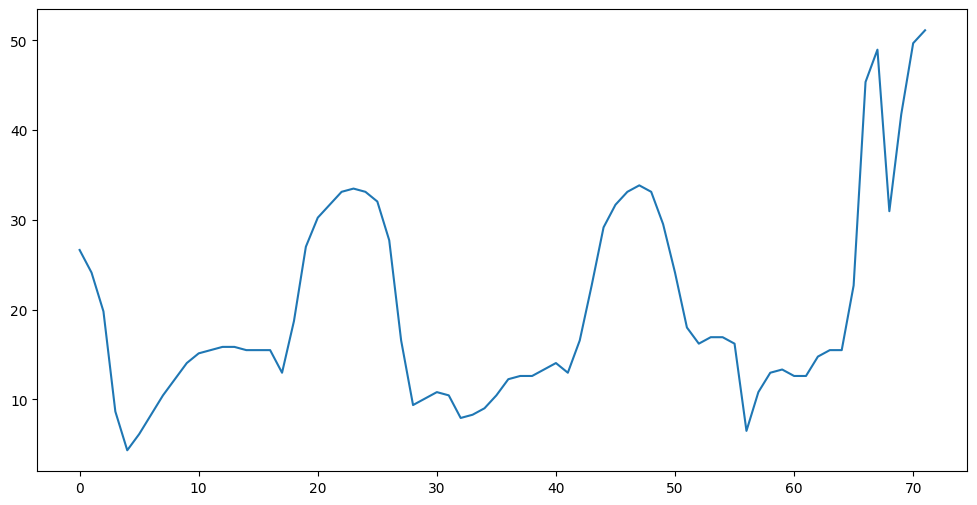

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(merged_df[merged_df["extreme"] == 1].iloc[0]["prev_72h_wind_gusts_10m"], label='Synthetic Sample 1 - Feature 1')


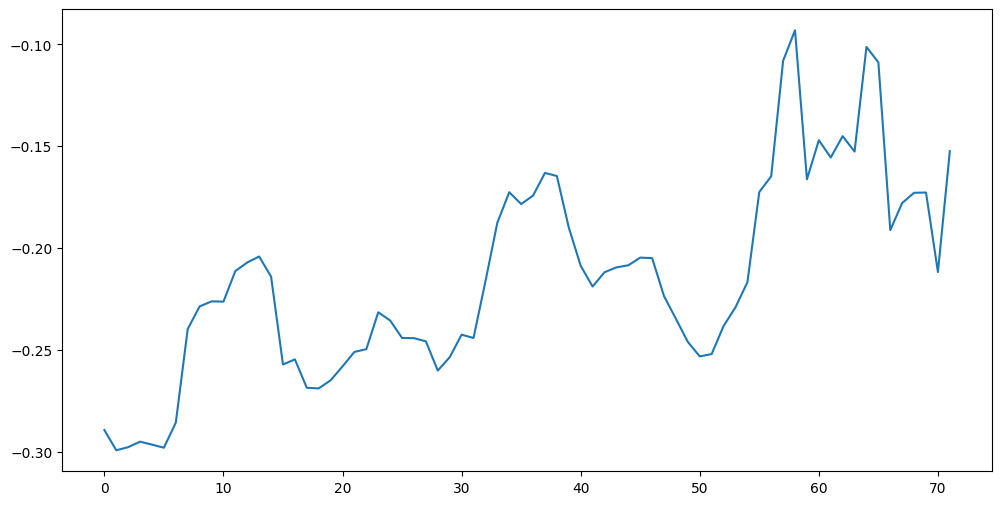

In [27]:
# crerate a line chart
import matplotlib.pyplot as plt

# Create a line chart for the first feature of the first synthetic sample
plt.figure(figsize=(12, 6))
plt.plot(oversampled_minority_data[5, 18, :], label='Synthetic Sample 1 - Feature 1')


## Data inspection

In [6]:
meteo_cols

['prev_72h_temperature_2m',
 'prev_72h_relative_humidity_2m',
 'prev_72h_dew_point_2m',
 'prev_72h_apparent_temperature',
 'prev_72h_precipitation',
 'prev_72h_rain',
 'prev_72h_pressure_msl',
 'prev_72h_surface_pressure',
 'prev_72h_cloud_cover',
 'prev_72h_cloud_cover_low',
 'prev_72h_cloud_cover_mid',
 'prev_72h_cloud_cover_high',
 'prev_72h_et0_fao_evapotranspiration',
 'prev_72h_vapour_pressure_deficit',
 'prev_72h_wind_speed_10m',
 'prev_72h_wind_speed_100m',
 'prev_72h_wind_direction_10m',
 'prev_72h_wind_direction_100m',
 'prev_72h_wind_gusts_10m',
 'prev_72h_soil_temperature_0_to_7cm',
 'prev_72h_soil_temperature_7_to_28cm',
 'prev_72h_soil_temperature_28_to_100cm',
 'prev_72h_soil_temperature_100_to_255cm',
 'prev_72h_soil_moisture_0_to_7cm',
 'prev_72h_soil_moisture_7_to_28cm',
 'prev_72h_soil_moisture_28_to_100cm',
 'prev_72h_soil_moisture_100_to_255cm']

In [8]:
np.stack(merged_df[meteo_cols].values.tolist(), axis=0).shape

(35137, 27, 72)

In [2]:
merged_df.info()

NameError: name 'merged_df' is not defined

In [9]:
merged_df["event_type"].value_counts()

event_type
Flash Flood    14733
Flood          13440
Heavy Rain      6576
Name: count, dtype: int64

In [16]:
merged_df_copy = merged_df[merged_df["event_type"].isin(["Flash Flood", "Flood","Heavy Rain"])].copy()

In [17]:
merged_df_copy["prev_72h_temperature_2m"]

0        [20.732500076293945, 20.932498931884766, 20.33...
1        [23.432498931884766, 23.182498931884766, 22.78...
2        [19.982500076293945, 20.482500076293945, 20.73...
3        [18.298999786376953, 17.948999404907227, 17.79...
4        [25.18899917602539, 24.388999938964844, 22.239...
                               ...                        
35132    [24.821001052856445, 24.621000289916992, 24.42...
35133    [19.906999588012695, 18.85700035095215, 17.957...
35134    [26.688499450683594, 25.28849983215332, 23.638...
35135    [26.618499755859375, 21.7185001373291, 21.3185...
35136    [27.980501174926758, 27.230501174926758, 25.23...
Name: prev_72h_temperature_2m, Length: 34749, dtype: object

In [18]:
merged_df_copy[merged_df_copy["extreme"] == 1].sample(1).iloc[0]

event_type                                                                      Flash Flood
begin_date_time                                                         2017-09-06 15:23:00
cz_timezone                                                                           AST-4
end_date_time                                                           2017-09-06 23:15:00
begin_lat                                                                             18.36
begin_lon                                                                            -66.34
end_lat                                                                               18.36
end_lon                                                                               -66.3
extreme                                                                                   1
begin_date_utc                                                                   2017-09-06
begin_time_utc                                                                  

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout,
                                     LSTM, Dense, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model # Import Model for Functional API
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, Activation,
    LSTM, Bidirectional, Dropout, Dense, LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import relevant metrics for classification, especially if data is imbalanced
from tensorflow.keras.metrics import Precision, Recall, AUC
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Data Preparation ---
# Assume merged_df and meteo_cols are defined earlier in your code.
# For multi-class, we now use the "event_type" column.

# Encode the categorical labels to integer values
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df["event_type"].values)
# Number of classes (should be 10 based on provided counts)
num_classes = len(le.classes_)

# Convert integer labels to one-hot encoded format
y = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

# Prepare features (assuming meteo_cols contains your meteorological data)
# Here we simulate stacking the data; adjust if your actual data preprocessing is different.
X = np.stack(merged_df[meteo_cols].values.tolist(), axis=0)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale the data
scaler = StandardScaler()

# Reshape for scaling: combine timesteps and features
X_train = X_train.reshape(-1, X_train.shape[-1])
X_test = X_test.reshape(-1, X_test.shape[-1])

# Fit and transform
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape back to original structure: (samples, num_features, num_timesteps)
# Note: Here we assume the original shape was (samples, num_features, num_timesteps).
# Adjust reshaping if your data dimensions differ.
X_train = X_train.reshape(-1, 27, 72)
X_test = X_test.reshape(-1, 27, 72)

# Print shapes to verify correctness (should print something like (samples, 27, 72) and (samples, num_classes))
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# --- Reshape Input for Model ---
# Rearranging shape to (samples, timesteps, features), here timesteps=72 and features=27.
X_train = X_train.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)

num_timesteps = X_train.shape[1]  # should be 72
num_features  = X_train.shape[2]  # should be 27
input_layer = Input(shape=(num_timesteps, num_features))
# --- CNN Feature Extraction Block ---
# Conv Block 1
x = Conv1D(filters=64, kernel_size=3, padding='same')(input_layer)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.01)(x) # Using LeakyReLU instead of ReLU
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x) # Increased dropout slightly

# Conv Block 2
x = Conv1D(filters=128, kernel_size=5, padding='same')(x) # Larger kernel, more filters
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.01)(x)
# Optional: Add another MaxPooling here if needed, depends on sequence length
# x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)

# Conv Block 3
x = Conv1D(filters=128, kernel_size=7, padding='same')(x) # Even larger kernel
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.01)(x)
x = Dropout(0.3)(x)

# --- LSTM Sequence Processing Block ---
# Using Bidirectional LSTM adds complexity and captures dependencies in both directions
# Stacked BiLSTM layers
x = Bidirectional(LSTM(128, return_sequences=True))(x) # return_sequences=True for stacking
x = Dropout(0.4)(x) # Higher dropout for recurrent layers

x = Bidirectional(LSTM(64))(x) # Last LSTM layer doesn't need return_sequences=True
x = Dropout(0.4)(x)

# --- Dense Classification Block ---
# Intermediate Dense layer
x = Dense(64)(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.01)(x)
x = Dropout(0.5)(x) # Higher dropout before final layer

# Output layer
output_layer = Dense(3, activation='softmax')(x)

# Create the Model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model with potentially more informative metrics
# Consider a lower learning rate for potentially more complex models
optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy',
                       Precision(name='precision'),
                       Recall(name='recall')]) # AUC is good for binary classification

model.summary()

# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# --- Class Weights ---
# Calculate class weights using the original integer labels (y_encoded)
counts = np.bincount(y_encoded[train_test_split(range(len(y_encoded)), 
                                                 test_size=0.2, random_state=42, stratify=y_encoded)[0]])
# Ensure we compute weights for all classes
if len(counts) == num_classes:
    class_weight = {i: (1 / count) * (len(y_train)) / num_classes for i, count in enumerate(counts)}
    print("Calculated Class Weights:", class_weight)
else:
    class_weight = None
    print("Mismatch in class counts; skipping class weight computation.")

# --- Train the Model ---
epochs = 50
batch_size = 32

history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.2,
                    callbacks=[early_stopping, reduce_lr],
                    class_weight=class_weight,
                    verbose=1)




X_train shape: (27799, 27, 72)
y_train shape: (27799, 3)


c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 72, 27)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ (None, 72, 64)         │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 72, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_36 (LeakyReLU)      │ (None, 72, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 36, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 36, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_36 (Conv1D)              │ (None, 36, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 36, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_37 (LeakyReLU)      │ (None, 36, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 36, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_37 (Conv1D)              │ (None, 36, 128)        │       114,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 36, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_38 (LeakyReLU)      │ (None, 36, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 36, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_19                │ (None, 36, 256)        │       263,168 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 36, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_20                │ (None, 128)            │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_39 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 64)             │             

 Total params: 598,659 (2.28 MB)

 Trainable params: 597,891 (2.28 MB)

 Non-trainable params: 768 (3.00 KB)

Calculated Class Weights: {0: np.float64(0.7862152836698909), 1: np.float64(0.8618241567460316), 2: np.float64(1.761325476778813)}
Epoch 1/50
695/695 ━━━━━━━━━━━━━━━━━━━━ 63s 78ms/step - accuracy: 0.4020 - loss: 1.3777 - precision: 0.4172 - recall: 0.3403 - val_accuracy: 0.4707 - val_loss: 1.1285 - val_precision: 0.4890 - val_recall: 0.4115 - learning_rate: 1.0000e-04
Epoch 2/50
695/695 ━━━━━━━━━━━━━━━━━━━━ 58s 83ms/step - accuracy: 0.5219 - loss: 1.0805 - precision: 0.5505 - recall: 0.4431 - val_accuracy: 0.5466 - val_loss: 1.0082 - val_precision: 0.5702 - val_recall: 0.4903 - learning_rate: 1.0000e-04
Epoch 3/50
695/695 ━━━━━━━━━━━━━━━━━━━━ 58s 83ms/step - accuracy: 0.5435 - loss: 0.9907 - precision: 0.5873 - recall: 0.4522 - val_accuracy: 0.5942 - val_loss: 0.9400 - val_precision: 0.6267 - val_recall: 0.5182 - learning_rate: 1.0000e-04
Epoch 4/50
695/695 ━━━━━━━━━━━━━━━━━━━━ 59s 85ms/step - accuracy: 0.5681 - loss: 0.9475 - precision: 0.6105 - recall: 0.4622 - val_accuracy: 0.6331 -

KeyboardInterrupt: 

In [30]:
# --- Evaluate the Model ---
print("\nEvaluating model on test set:")
results = model.evaluate(X_test, y_test, batch_size=batch_size, verbose=1)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")
print(f"Test Precision: {results[2]:.4f}")
print(f"Test Recall: {results[3]:.4f}")


Evaluating model on test set:
218/218 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.7634 - loss: 0.5837 - precision: 0.7925 - recall: 0.7195
Test Loss: 0.5945
Test Accuracy: 0.7586
Test Precision: 0.7881
Test Recall: 0.7150


In [32]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout,
                                     LSTM, Dense, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model # Import Model for Functional API
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, Activation,
    LSTM, Bidirectional, Dropout, Dense, LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import relevant metrics for classification, especially if data is imbalanced
from tensorflow.keras.metrics import Precision, Recall, AUC
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Data Preparation ---
# Assume merged_df and meteo_cols are defined earlier in your code.
# For multi-class, we now use the "event_type" column.

# Encode the categorical labels to integer values
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df["event_type"].values)
# Number of classes (should be 10 based on provided counts)
num_classes = len(le.classes_)

# Convert integer labels to one-hot encoded format
y = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

# Prepare features (assuming meteo_cols contains your meteorological data)
# Here we simulate stacking the data; adjust if your actual data preprocessing is different.
X = np.stack(merged_df[meteo_cols].values.tolist(), axis=0)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale the data
scaler = StandardScaler()

# Reshape for scaling: combine timesteps and features
X_train = X_train.reshape(-1, X_train.shape[-1])
X_test = X_test.reshape(-1, X_test.shape[-1])

# Fit and transform
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape back to original structure: (samples, num_features, num_timesteps)
# Note: Here we assume the original shape was (samples, num_features, num_timesteps).
# Adjust reshaping if your data dimensions differ.
X_train = X_train.reshape(-1, 27, 72)
X_test = X_test.reshape(-1, 27, 72)

# Print shapes to verify correctness (should print something like (samples, 27, 72) and (samples, num_classes))
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# --- Reshape Input for Model ---
# Rearranging shape to (samples, timesteps, features), here timesteps=72 and features=27.
X_train = X_train.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)

num_timesteps = X_train.shape[1]  # should be 72
num_features  = X_train.shape[2]  # should be 27
input_layer = Input(shape=(num_timesteps, num_features))
# --- CNN Feature Extraction Block ---
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Dense, Bidirectional, LSTM, GlobalAveragePooling1D, Attention
from tensorflow.keras.optimizers import Adam



# --- Conv Block 1 ---
conv1 = Conv1D(filters=64, kernel_size=3, padding='same')(input_layer)
conv1 = BatchNormalization()(conv1)
conv1 = LeakyReLU(alpha=0.01)(conv1)  # using LeakyReLU instead of ReLU
conv1 = MaxPooling1D(pool_size=2)(conv1)
conv1 = Dropout(0.3)(conv1)

# --- Conv Block 2 ---
conv2 = Conv1D(filters=128, kernel_size=5, padding='same')(conv1)  # larger kernel, more filters
conv2 = BatchNormalization()(conv2)
conv2 = LeakyReLU(alpha=0.01)(conv2)
conv2 = Dropout(0.3)(conv2)

# --- Residual Connection ---
# Adjust conv1 dimensions to match conv2 via 1x1 convolution
shortcut = Conv1D(filters=128, kernel_size=1, padding='same')(conv1)
shortcut = BatchNormalization()(shortcut)
res = Add()([conv2, shortcut])

# --- Conv Block 3 ---
conv3 = Conv1D(filters=128, kernel_size=7, padding='same')(res)  # even larger kernel
conv3 = BatchNormalization()(conv3)
conv3 = LeakyReLU(alpha=0.01)(conv3)
conv3 = Dropout(0.3)(conv3)

# --- LSTM Sequence Processing Block ---
# Stacked Bidirectional LSTM with return_sequences=True to retain the full sequence output
x = Bidirectional(LSTM(128, return_sequences=True))(conv3)
x = Dropout(0.4)(x)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.4)(x)

# --- Attention Mechanism ---
# Using Keras built-in Attention layer for self-attention over the LSTM outputs.
# It takes [query, value] where both are the same in self-attention.
attn_out = Attention()([x, x])
# Global average pooling aggregates the attended sequence into a fixed-size vector.
x = GlobalAveragePooling1D()(attn_out)

# --- Dense Classification Block ---
x = Dense(64)(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.01)(x)
x = Dropout(0.5)(x)

# --- Output Layer ---
output_layer = Dense(3, activation='softmax')(x)

# --- Build and Compile the Model ---
model_1 = Model(inputs=input_layer, outputs=output_layer)

optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model_1.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy',
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])

model_1.summary()

# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# --- Class Weights ---
# Calculate class weights using the original integer labels (y_encoded)
counts = np.bincount(y_encoded[train_test_split(range(len(y_encoded)), 
                                                 test_size=0.2, random_state=42, stratify=y_encoded)[0]])
# Ensure we compute weights for all classes
if len(counts) == num_classes:
    class_weight = {i: (1 / count) * (len(y_train)) / num_classes for i, count in enumerate(counts)}
    print("Calculated Class Weights:", class_weight)
else:
    class_weight = None
    print("Mismatch in class counts; skipping class weight computation.")

# --- Train the Model ---
epochs = 50
batch_size = 32

history_1 = model_1.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.2,
                    callbacks=[early_stopping, reduce_lr],
                    class_weight=class_weight,
                    verbose=1)




X_train shape: (27799, 27, 72)
y_train shape: (27799, 3)


c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_48"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 72, 27)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_42 (Conv1D)  │ (None, 72, 64)    │      5,248 │ input_layer_20[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 64)    │        256 │ conv1d_42[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_44      │ (None, 72, 64)    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_19    │ (None, 36, 64)    │          0 │ leaky_re_lu_44[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_81          │ (None, 36, 64)    │          0 │ max_pooling1d_19… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_43 (Conv1D)  │ (None, 36, 128)   │     41,088 │ dropout_81[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 128)   │        512 │ conv1d_43[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_45      │ (None, 36, 128)   │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_44 (Conv1D)  │ (None, 36, 128)   │      8,320 │ dropout_81[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_82          │ (None, 36, 128)   │          0 │ leaky_re_lu_45[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 128)   │        512 │ conv1d_44[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 36, 128)   │          0 │ dropout_82[0][0], │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_45 (Conv1D)  │ (None, 36, 128)   │    114,816 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 128)   │        512 │ conv1d_45[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_46      │ (None, 36, 128)   │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_83          │ (None, 36, 128)   │          0 │ leaky_re_lu_46[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_23    │ (None, 36, 256)   │    263,168 │ dropout_83[0][0]  │
│ (Bidirectional)     │                   │            │                 

 Total params: 607,491 (2.32 MB)

 Trainable params: 606,467 (2.31 MB)

 Non-trainable params: 1,024 (4.00 KB)

Calculated Class Weights: {0: np.float64(0.7862152836698909), 1: np.float64(0.8618241567460316), 2: np.float64(1.761325476778813)}
Epoch 1/50
695/695 ━━━━━━━━━━━━━━━━━━━━ 71s 93ms/step - accuracy: 0.4575 - loss: 1.2060 - precision: 0.4818 - recall: 0.3784 - val_accuracy: 0.5811 - val_loss: 0.9447 - val_precision: 0.6096 - val_recall: 0.5140 - learning_rate: 1.0000e-04
Epoch 2/50
695/695 ━━━━━━━━━━━━━━━━━━━━ 68s 97ms/step - accuracy: 0.5165 - loss: 1.0330 - precision: 0.5535 - recall: 0.4159 - val_accuracy: 0.6068 - val_loss: 0.8962 - val_precision: 0.6351 - val_recall: 0.5460 - learning_rate: 1.0000e-04
Epoch 3/50
695/695 ━━━━━━━━━━━━━━━━━━━━ 70s 100ms/step - accuracy: 0.5442 - loss: 0.9630 - precision: 0.5921 - recall: 0.4356 - val_accuracy: 0.6004 - val_loss: 0.8926 - val_precision: 0.6309 - val_recall: 0.5471 - learning_rate: 1.0000e-04
Epoch 4/50
695/695 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.5742 - loss: 0.9078 - precision: 0.6273 - recall: 0.4616 - val_accuracy: 0.6320

KeyboardInterrupt: 

In [16]:
merged_df = merged_df[merged_df["event_type"].isin(["Flash Flood", "Flood","Heavy Rain"])].copy()

In [19]:
merged_df["extreme"].value_counts()

extreme
0    31386
1     3363
Name: count, dtype: int64

In [20]:
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler



# Initialize the RandomOverSampler
oversample = RandomOverSampler(sampling_strategy='minority', random_state=42)

# Apply the oversampling to the dataset
X_resampled, y_resampled = oversample.fit_resample(merged_df.drop(columns=["extreme"]), merged_df["extreme"])

# Display class distribution after oversampling
print("Class distribution after oversampling:", Counter(y_resampled))


Class distribution after oversampling: Counter({0: 31386, 1: 31386})


In [30]:
import pandas as pd
import numpy as np

# Example datetime string
dt_str = "2012-10-29 12:30:00"
dt = pd.to_datetime(dt_str)

# Extract features
year = dt.year         # 2012
month = dt.month       # 10
day = dt.day           # 29
hour = dt.hour         # 12
minute = dt.minute     # 30
day_of_week = dt.dayofweek  # 0=Monday, 6=Sunday, for example

# Encode the hour cyclically
hour_rad = 2 * np.pi * hour / 24
sin_hour = np.sin(hour_rad)
cos_hour = np.cos(hour_rad)

print(f"Year: {year}, Month: {month}, Day: {day}, Day of Week: {day_of_week}")
print(f"Hour: {hour}, Sin(hour): {sin_hour:.2f}, Cos(hour): {cos_hour:.2f}")


Year: 2012, Month: 10, Day: 29, Day of Week: 0
Hour: 12, Sin(hour): 0.00, Cos(hour): -1.00


In [39]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout,
                                     LSTM, Dense, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model # Import Model for Functional API
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, Activation,
    LSTM, Bidirectional, Dropout, Dense, LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import relevant metrics for classification, especially if data is imbalanced
from tensorflow.keras.metrics import Precision, Recall, AUC
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Data Preparation ---
# Assume merged_df and meteo_cols are defined earlier in your code.
# For multi-class, we now use the "event_type" column.

# Encode the categorical labels to integer values
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df["event_type"].values)
# Number of classes (should be 10 based on provided counts)
num_classes = len(le.classes_)

# Convert integer labels to one-hot encoded format
y = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)
y_bin = merged_df["extreme"].values # Binary labels for extreme events
# Prepare features (assuming meteo_cols contains your meteorological data)
# Here we simulate stacking the data; adjust if your actual data preprocessing is different.


# Split the data into training and testing sets
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    merged_df[meteo_cols], y,y_bin, test_size=0.2, random_state=42, stratify=y_bin
)


X_train, X_validation, y_train_bin, y_validation_bin = train_test_split(
    X_train,y_train_bin, test_size=0.2, random_state=42, stratify=y_train_bin
)
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
# Apply the oversampling to the dataset
oversample = RandomOverSampler(sampling_strategy='minority', random_state=42)
X_resampled, y_resampled = oversample.fit_resample(X_train,y_train_bin)


X_resampled = np.stack(X_resampled[meteo_cols].values.tolist(), axis=0)
X_test = np.stack(X_test[meteo_cols].values.tolist(), axis=0)
X_validation = np.stack(X_validation[meteo_cols].values.tolist(), axis=0)
# Initialize the RandomOverSampler

print("peecentage of positice instance in training data: ", sum(y_resampled)/len(y_resampled))
print("percentage of positice instance in test data: ", sum(y_test_bin)/len(y_test_bin))
print("percentage of positice instance in validation data: ", sum(y_validation_bin)/len(y_validation_bin))

print("y resampled shape:", y_resampled.shape)
# Display class distribution after oversampling
print("Class distribution after oversampling:", Counter(y_resampled))
# Scale the data
scaler = StandardScaler()

# Reshape for scaling: combine timesteps and features
X_resampled = X_resampled.reshape(-1, X_resampled.shape[-1])
X_test = X_test.reshape(-1, X_test.shape[-1])
X_validation = X_validation.reshape(-1, X_validation.shape[-1])
# Fit and transform
print("X resampled shape before scaling:", X_resampled.shape)
X_resampled = scaler.fit_transform(X_resampled)
X_test = scaler.transform(X_test)
X_validation = scaler.transform(X_validation)
# Reshape back to original structure: (samples, num_features, num_timesteps)
# Note: Here we assume the original shape was (samples, num_features, num_timesteps).
# Adjust reshaping if your data dimensions differ.
X_resampled = X_resampled.reshape(-1, 27, 72)
X_test = X_test.reshape(-1, 27, 72)
X_validation = X_validation.reshape(-1, 27, 72)
# Print shapes to verify correctness (should print something like (samples, 27, 72) and (samples, num_classes))
print("X_train shape:", X_resampled.shape)
print("y_train shape:", y_resampled.shape)

# --- Reshape Input for Model ---
# Rearranging shape to (samples, timesteps, features), here timesteps=72 and features=27.
X_resampled = X_resampled.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)
X_validation = X_validation.transpose(0, 2, 1)
num_timesteps = X_resampled.shape[1]  # should be 72
num_features  = X_resampled.shape[2]  # should be 27
input_layer = Input(shape=(num_timesteps, num_features))
# --- CNN Feature Extraction Block ---
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Dense, Bidirectional, LSTM, GlobalAveragePooling1D, Attention
from tensorflow.keras.optimizers import Adam






# --- Shared Conv Block 1 ---
conv1 = Conv1D(filters=64, kernel_size=3, padding='same')(input_layer)
conv1 = BatchNormalization()(conv1)
conv1 = LeakyReLU(alpha=0.01)(conv1)
conv1 = MaxPooling1D(pool_size=2)(conv1)
conv1 = Dropout(0.3)(conv1)

# --- Shared Conv Block 2 ---
conv2 = Conv1D(filters=128, kernel_size=5, padding='same')(conv1)
conv2 = BatchNormalization()(conv2)
conv2 = LeakyReLU(alpha=0.01)(conv2)
conv2 = Dropout(0.3)(conv2)

# --- Residual Connection from Conv Block 1 ---
shortcut = Conv1D(filters=128, kernel_size=1, padding='same')(conv1)
shortcut = BatchNormalization()(shortcut)
res = Add()([conv2, shortcut])

# --- Shared Conv Block 3 ---
conv3 = Conv1D(filters=128, kernel_size=7, padding='same')(res)
conv3 = BatchNormalization()(conv3)
conv3 = LeakyReLU(alpha=0.01)(conv3)
conv3 = Dropout(0.3)(conv3)

# --- Shared LSTM Sequence Processing Block ---
x = Bidirectional(LSTM(128, return_sequences=True))(conv3)
x = Dropout(0.4)(x)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.4)(x)

# --- Shared Attention Mechanism ---
# Using built-in Keras Attention layer (self-attention)
attn_out = Attention()([x, x])
# Aggregate attended features into a fixed-size vector
shared_features = GlobalAveragePooling1D()(attn_out)

# --- Event Type Classification Head ---
event_branch = Dense(64)(shared_features)
event_branch = BatchNormalization()(event_branch)
event_branch = LeakyReLU(alpha=0.01)(event_branch)
event_branch = Dropout(0.5)(event_branch)
event_output = Dense(3, activation='softmax', name='event_type')(event_branch)

# --- Extreme Event Classification Head ---
extreme_branch = Dense(64)(shared_features)
extreme_branch = BatchNormalization()(extreme_branch)
extreme_branch = LeakyReLU(alpha=0.01)(extreme_branch)
extreme_branch = Dropout(0.5)(extreme_branch)
extreme_output = Dense(1, activation='sigmoid', name='extreme')(extreme_branch)

# --- Create and Compile the Multi-task Model ---
model = Model(inputs=input_layer, outputs=extreme_output)

optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
# model.compile(optimizer=optimizer,
#               loss={'event_type': 'categorical_crossentropy', 'extreme': 'binary_crossentropy'},
#               metrics={'event_type': ['accuracy'], 'extreme': [tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]})

model.compile(optimizer=optimizer,
              loss={'extreme': 'binary_crossentropy'},
              metrics={'extreme': [tf.keras.metrics.Accuracy(name='accuracy'), tf.keras.metrics.Precision(), tf.keras.metrics.Recall(),  tf.keras.metrics.AUC(name='roc_auc'), tf.keras.metrics.AUC(curve='PR', name='pr_auc') ]})

model.summary()

# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# --- Class Weights ---
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',   # This option adjusts weights inversely proportional to class frequencies in the input data
    classes=np.unique(y_resampled),  # List of unique class labels
    y=y_resampled  # Your target variable (e.g., labels)
)

# Convert class_weights to a dictionary format
class_weight = dict(zip(np.unique(y_resampled), class_weights))
# --- Train the Model ---
epochs = 50
batch_size = 32
print("y resampe shape", y_resampled.shape)
history_1 = model.fit(X_resampled,  y_resampled,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.2,
                    callbacks=[early_stopping, reduce_lr],
                    validation_data=(X_validation, y_validation_bin),
                    class_weight=class_weight,
                    verbose=1)




peecentage of positice instance in training data:  0.5
percentage of positice instance in test data:  0.09846328969834946
percentage of positice instance in validation data:  0.0983635716826752
y resampled shape: (40546,)
Class distribution after oversampling: Counter({np.int64(0): 20273, np.int64(1): 20273})
X resampled shape before scaling: (1094742, 72)
X_train shape: (40546, 27, 72)
y_train shape: (40546,)


c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_24      │ (None, 72, 27)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_43 (Conv1D)  │ (None, 72, 64)    │      5,248 │ input_layer_24[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 64)    │        256 │ conv1d_43[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_39      │ (None, 72, 64)    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 36, 64)    │          0 │ leaky_re_lu_39[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_86          │ (None, 36, 64)    │          0 │ max_pooling1d_5[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_44 (Conv1D)  │ (None, 36, 128)   │     41,088 │ dropout_86[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 128)   │        512 │ conv1d_44[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_40      │ (None, 36, 128)   │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_45 (Conv1D)  │ (None, 36, 128)   │      8,320 │ dropout_86[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_87          │ (None, 36, 128)   │          0 │ leaky_re_lu_40[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 128)   │        512 │ conv1d_45[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 36, 128)   │          0 │ dropout_87[0][0], │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_46 (Conv1D)  │ (None, 36, 128)   │    114,816 │ add_13[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 128)   │        512 │ conv1d_46[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_41      │ (None, 36, 128)   │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_88          │ (None, 36, 128)   │          0 │ leaky_re_lu_41[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_10    │ (None, 36, 256)   │    263,168 │ dropout_88[0][0]  │
│ (Bidirectional)     │                   │            │                 

 Total params: 607,361 (2.32 MB)

 Trainable params: 606,337 (2.31 MB)

 Non-trainable params: 1,024 (4.00 KB)

y resampe shape (40546,)
Epoch 1/50
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 95s 68ms/step - accuracy: 0.0000e+00 - loss: 0.7645 - pr_auc: 0.5584 - precision_6: 0.5420 - recall_6: 0.5310 - roc_auc: 0.5633 - val_accuracy: 0.0000e+00 - val_loss: 0.6042 - val_pr_auc: 0.1968 - val_precision_6: 0.1541 - val_recall_6: 0.5190 - val_roc_auc: 0.6486 - learning_rate: 1.0000e-04
Epoch 2/50
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 93s 73ms/step - accuracy: 0.0000e+00 - loss: 0.6895 - pr_auc: 0.6218 - precision_6: 0.5857 - recall_6: 0.5948 - roc_auc: 0.6298 - val_accuracy: 0.0000e+00 - val_loss: 0.6219 - val_pr_auc: 0.2304 - val_precision_6: 0.1583 - val_recall_6: 0.6347 - val_roc_auc: 0.6826 - learning_rate: 1.0000e-04
Epoch 3/50
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 106s 84ms/step - accuracy: 0.0000e+00 - loss: 0.6567 - pr_auc: 0.6562 - precision_6: 0.6145 - recall_6: 0.6221 - roc_auc: 0.6680 - val_accuracy: 0.0000e+00 - val_loss: 0.5163 - val_pr_auc: 0.2308 - val_precision_6: 0.1907 - val_recall_6: 0.4955 - val_roc_auc: 0

KeyboardInterrupt: 

In [28]:
print(model.predict(X_test))

393/393 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step


array([[0.43097556],
       [0.50943565],
       [0.5353495 ],
       ...,
       [0.8986355 ],
       [0.22697534],
       [0.09261929]], dtype=float32)

176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
Optimal threshold: 0.7899999999999996, F1 score: 0.3834
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step
Test Accuracy: 0.8729
Test Precision: 0.3723
Test Recall: 0.4234
Test F1-Score: 0.3962
Test ROC AUC: 0.7826


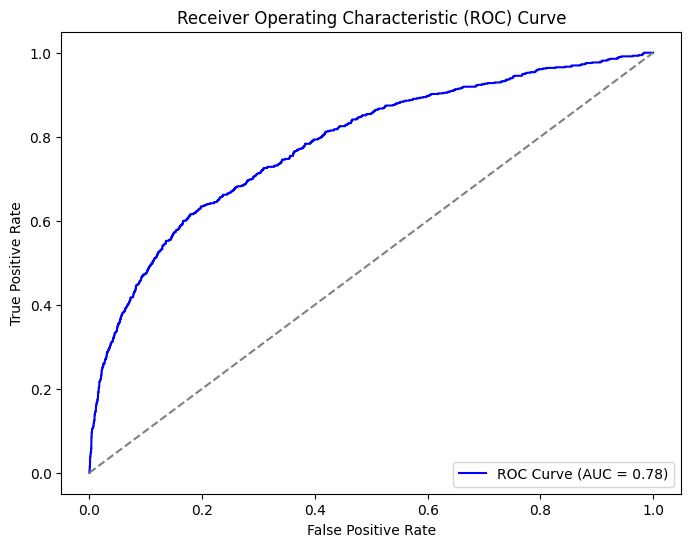

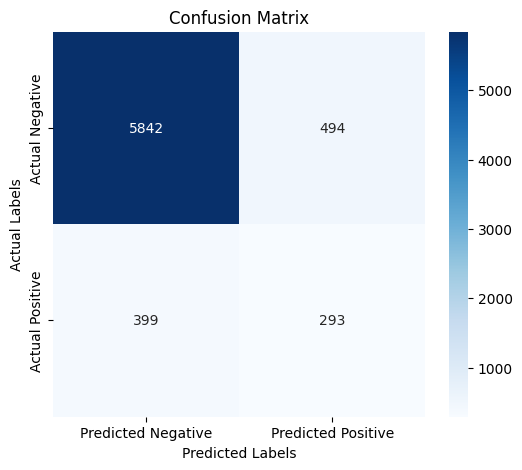

In [45]:
# After training, find optimal threshold for F1 score instead of default 0.5
def find_optimal_threshold(model, x_val, y_val):
    y_pred_prob = model.predict(x_val)
    
    best_f1 = 0
    best_threshold = 0.5
    
    for threshold in np.arange(0.1, 0.9, 0.01):
        y_pred = (y_pred_prob > threshold).astype(int)
        precision = tf.keras.metrics.Precision()(y_val, y_pred).numpy()
        recall = tf.keras.metrics.Recall()(y_val, y_pred).numpy()
        
        if precision + recall > 0:  # Avoid division by zero
            f1 = 2 * (precision * recall) / (precision + recall)
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold
    
    print(f"Optimal threshold: {best_threshold}, F1 score: {best_f1:.4f}")
    return best_threshold

# Use the optimal threshold for final predictions
optimal_threshold = find_optimal_threshold(model, X_validation, y_validation_bin)
y_pred = (model.predict(X_test) > optimal_threshold).astype(int)

precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_probs)
accuracy = accuracy_score(y_test_bin, y_pred)

# 4. Display the metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

# 5. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_bin, y_probs)

# 6. Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# 7. Compute confusion matrix
cm = confusion_matrix(y_test_bin, y_pred)

# 8. Plot confusion matrix using Seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()

220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step
Test Accuracy: 0.7612
Test Precision: 0.2378
Test Recall: 0.6460
Test F1-Score: 0.3476
Test ROC AUC: 0.7826


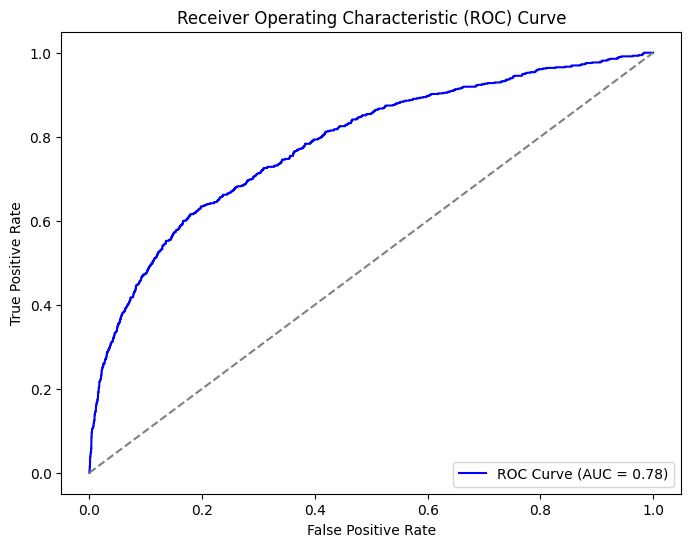

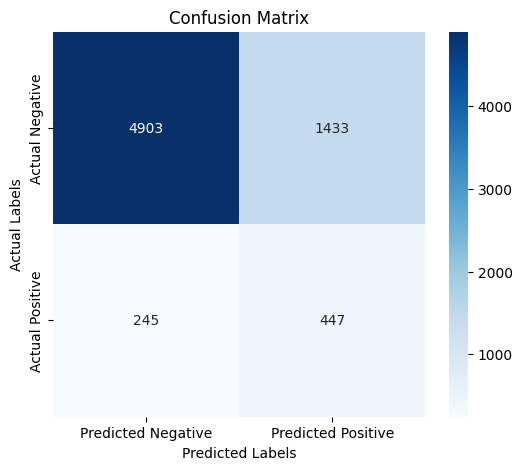

In [40]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, accuracy_score)
from sklearn.preprocessing import LabelBinarizer

# Assuming 'model' is your trained model and 'X_test', 'y_test' are your test data and labels

# 1. Obtain predicted probabilities for the positive class
y_probs = model.predict(X_test).flatten() # Adjust indexing if your model has multiple outputs

# 2. Binarize the true labels if they are not already in binary forma

# 3. Compute evaluation metrics
y_pred = (y_probs > 0.5).astype(int)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_probs)
accuracy = accuracy_score(y_test_bin, y_pred)

# 4. Display the metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

# 5. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_bin, y_probs)

# 6. Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# 7. Compute confusion matrix
cm = confusion_matrix(y_test_bin, y_pred)

# 8. Plot confusion matrix using Seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()


In [11]:
precision = results[2]
recall = results[3]

# Calculate F1 Score
f1_score = 2 * (precision * recall) / (precision + recall)

# Display the F1 Score
print(f"Test F1 Score: {f1_score:.4f}")

NameError: name 'results' is not defined

In [16]:
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, LeakyReLU, ReLU, Add, Dropout,
                                     Dense, GlobalAveragePooling1D, LayerNormalization, MultiHeadAttention,
                                     Layer, Embedding, Input, SpatialDropout1D)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import math
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, LeakyReLU, ReLU, Add, Dropout,
                                     Dense, GlobalAveragePooling1D, LayerNormalization, MultiHeadAttention,
                                     Layer, Embedding, Input, SpatialDropout1D)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import math

# --- Shared Configuration ---
INPUT_SHAPE = (72, 27) # (time_steps, num_features)
NUM_CLASSES = 1        # Binary classification for 'extreme'
LEARNING_RATE = 1e-4
CLIPNORM = 1.0

# --- Metrics (same as your last model) ---
METRICS = [
    tf.keras.metrics.Accuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='roc_auc'),
    tf.keras.metrics.AUC(curve='PR', name='pr_auc')
]
# --- TCN Residual Block ---
def TCNBlock(input_tensor, filters, kernel_size, dilation_rate, dropout_rate=0.2, activation='relu'):
    """A single TCN residual block."""
    # Ensure causal padding
    conv1 = Conv1D(filters=filters, kernel_size=kernel_size, dilation_rate=dilation_rate,
                   padding='causal', kernel_initializer='he_normal')(input_tensor)
    # Using LayerNorm instead of BatchNorm is sometimes preferred in sequence models
    norm1 = LayerNormalization()(conv1)
    # Using ReLU is more common in TCN literature than LeakyReLU
    act1 = ReLU()(norm1) if activation == 'relu' else LeakyReLU(alpha=0.01)(norm1)
    drop1 = SpatialDropout1D(dropout_rate)(act1) # SpatialDropout drops entire feature maps

    conv2 = Conv1D(filters=filters, kernel_size=kernel_size, dilation_rate=dilation_rate,
                   padding='causal', kernel_initializer='he_normal')(drop1)
    norm2 = LayerNormalization()(conv2)
    act2 = ReLU()(norm2) if activation == 'relu' else LeakyReLU(alpha=0.01)(norm2)
    drop2 = SpatialDropout1D(dropout_rate)(act2)

    # Residual connection (project input if number of filters differs)
    if input_tensor.shape[-1] != filters:
        shortcut = Conv1D(filters=filters, kernel_size=1, padding='same', kernel_initializer='he_normal')(input_tensor)
    else:
        shortcut = input_tensor

    res = Add()([shortcut, drop2])
    # Optional: Activation after Add (some TCN versions do, some don't)
    # res = ReLU()(res) if activation == 'relu' else LeakyReLU(alpha=0.01)(res)
    return res

# --- Build the TCN Model ---
def build_tcn_model(input_shape, num_classes, num_tcn_blocks=4, filters=64,
                      kernel_size=3, dropout_rate=0.2, final_dropout=0.5):
    """Builds the TCN model."""
    input_layer = Input(shape=input_shape)
    x = input_layer

    # Stack TCN Blocks with increasing dilation
    for i in range(num_tcn_blocks):
        dilation_rate = 2**i
        # Increase filters in deeper layers (optional)
        current_filters = filters * (2**(i // 2)) # e.g., 64, 64, 128, 128
        x = TCNBlock(x, filters=current_filters, kernel_size=kernel_size,
                     dilation_rate=dilation_rate, dropout_rate=dropout_rate)

    # Aggregate features over time
    x = GlobalAveragePooling1D()(x) # Or use x = x[:, -1, :] to take the last time step output

    # Classification Head
    x = Dense(64)(x)
    x = LayerNormalization()(x) # Using LayerNorm here too
    x = LeakyReLU(alpha=0.01)(x)
    x = Dropout(final_dropout)(x)
    output_layer = Dense(num_classes, activation='sigmoid', name='extreme')(x) # Sigmoid for binary

    model = Model(inputs=input_layer, outputs=output_layer)
    return model

# --- Create and Compile TCN Model ---
print("--- Building TCN Model ---")
tcn_model = build_tcn_model(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES,
    num_tcn_blocks=4, # Adjust number of blocks
    filters=64,       # Starting filters
    kernel_size=3,    # Kernel size for TCN blocks
    dropout_rate=0.2, # Dropout within TCN blocks
    final_dropout=0.5 # Dropout in the final classification head
)

optimizer_tcn = Adam(learning_rate=LEARNING_RATE, clipnorm=CLIPNORM)
tcn_model.compile(optimizer=optimizer_tcn,
                  loss='binary_crossentropy',
                  metrics=METRICS)

tcn_model.summary()
# --- Positional Encoding ---
# Necessary for Transformers to understand sequence order
class PositionalEncoding(Layer):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.pos_encoding = self.positional_encoding(position, d_model)

    def get_config(self):
        config = super().get_config().copy()
        config.update({
            'position': self.pos_encoding.shape[1],
             'd_model': self.pos_encoding.shape[2],
         })
        return config

    def positional_encoding(self, position, d_model):
        angle_rads = self.get_angles(np.arange(position)[:, np.newaxis],
                                     np.arange(d_model)[np.newaxis, :],
                                     d_model)
        # apply sin to even indices in the array; 2i
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        # apply cos to odd indices in the array; 2i+1
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        pos_encoding = angle_rads[np.newaxis, ...]
        return tf.cast(pos_encoding, dtype=tf.float32)

    def get_angles(self, pos, i, d_model):
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        return pos * angle_rates

    def call(self, inputs):
        seq_len = tf.shape(inputs)[1]
        # Ensure positional encoding is not longer than the input sequence
        return inputs + self.pos_encoding[:, :seq_len, :]


# --- Transformer Encoder Block ---
class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads) # Adjusted key_dim
        # Feed Forward Network
        self.ffn = tf.keras.Sequential(
            [Dense(ff_dim, activation="relu"), Dense(embed_dim),] # Use ReLU common in Transformers
        )
        # Layer Normalization
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        # Dropout
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def get_config(self):
        config = super().get_config().copy()
        config.update({
             'embed_dim': self.ffn.layers[1].units, # Get embed_dim from dense layer output
             'num_heads': self.att.num_heads,
             'ff_dim': self.ffn.layers[0].units, # Get ff_dim from dense layer units
             'dropout_rate': self.dropout1.rate # Assuming dropout rates are the same
         })
        return config

    def call(self, inputs, training=False):
        # Multi-Head Attention
        attn_output = self.att(inputs, inputs) # Self-attention
        # Dropout and Residual Connection
        out1 = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + out1)
        # Feed Forward Network
        ffn_output = self.ffn(out1)
        # Dropout and Residual Connection
        out2 = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + out2)
        return out2


# --- Build the Transformer Model ---
def build_transformer_model(input_shape, num_classes, num_transformer_blocks,
                             embed_dim, num_heads, ff_dim, dropout_rate=0.1,
                             final_dropout=0.5, mlp_units=64):
    """Builds the Transformer Encoder model."""
    time_steps = input_shape[0]
    num_features = input_shape[1]
    inputs = Input(shape=input_shape)

    # 1. Input Embedding/Projection
    # Project input features (27) to the embedding dimension (e.g., 128)
    # Using Conv1D allows mixing features across channels at each time step
    x = Conv1D(filters=embed_dim, kernel_size=1, activation='relu')(inputs)
    # Or use TimeDistributed Dense:
    # x = TimeDistributed(Dense(embed_dim, activation='relu'))(inputs)

    # 2. Add Positional Encoding
    x = PositionalEncoding(position=time_steps, d_model=embed_dim)(x)
    x = Dropout(dropout_rate)(x) # Dropout after embedding + pos encoding

    # 3. Stack Transformer Blocks
    for _ in range(num_transformer_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

    # 4. Pooling / Aggregation
    # Global Average Pooling aggregates across the time dimension
    x = GlobalAveragePooling1D()(x)
    # Optional: Use the output of the first token ([CLS] token style) if you design it that way

    # 5. Classification Head
    x = Dense(mlp_units)(x)
    x = LayerNormalization()(x) # Normalize before activation
    x = LeakyReLU(alpha=0.01)(x) # Or ReLU
    x = Dropout(final_dropout)(x)
    outputs = Dense(num_classes, activation="sigmoid", name="extreme")(x) # Sigmoid for binary

    model = Model(inputs=inputs, outputs=outputs)
    return model

# --- Create and Compile Transformer Model ---
print("\n--- Building Transformer Model ---")
transformer_model = build_transformer_model(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES,
    num_transformer_blocks=3, # Number of stacked encoder blocks (tune this)
    embed_dim=128,            # Embedding dimension (vector size for each time step)
    num_heads=8,              # Number of attention heads (must divide embed_dim)
    ff_dim=128,               # Hidden layer size in feed forward network (e.g., 4*embed_dim or smaller)
    dropout_rate=0.1,         # Dropout rate within Transformer blocks
    final_dropout=0.5,        # Dropout in the final classification head
    mlp_units=64              # Units in the classification head's hidden layer
)

optimizer_transformer = Adam(learning_rate=LEARNING_RATE, clipnorm=CLIPNORM)
transformer_model.compile(optimizer=optimizer_transformer,
                          loss='binary_crossentropy',
                          metrics=METRICS)

transformer_model.summary()

--- Building TCN Model ---


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 72, 27)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 72, 64)    │      5,248 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 72, 64)    │        128 │ conv1d_26[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 72, 64)    │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 72, 64)    │          0 │ re_lu[0][0]       │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_27 (Conv1D)  │ (None, 72, 64)    │     12,352 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 72, 64)    │        128 │ conv1d_27[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 72, 64)    │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 72, 64)    │      1,792 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 72, 64)    │          0 │ re_lu_1[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 72, 64)    │          0 │ conv1d_28[0][0],  │
│                     │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_29 (Conv1D)  │ (None, 72, 64)    │     12,352 │ add_8[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 72, 64)    │        128 │ conv1d_29[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 72, 64)    │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 72, 64)    │          0 │ re_lu_2[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_30 (Conv1D)  │ (None, 72, 64)    │     12,352 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 72, 64)    │        128 │ conv1d_30[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 72, 64)    │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_3 │ (None, 72, 64)    │          0 │ re_lu_3[0][0]     │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 72, 64)    │          0 │ add_8[0][0],    

 Total params: 234,945 (917.75 KB)

 Trainable params: 234,945 (917.75 KB)

...

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 72, 27)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_36 (Conv1D)              │ (None, 72, 128)        │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 72, 128)        │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 72, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 72, 128)        │        99,584 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 72, 128)        │        99,584 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 72, 128)        │        99,584 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_15          │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_34 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ extreme (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 310,785 (1.19 MB)

 Trainable params: 310,785 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout,
                                     LSTM, Dense, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model # Import Model for Functional API
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, Activation,
    LSTM, Bidirectional, Dropout, Dense, LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import relevant metrics for classification, especially if data is imbalanced
from tensorflow.keras.metrics import Precision, Recall, AUC
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Data Preparation ---
# Assume merged_df and meteo_cols are defined earlier in your code.
# For multi-class, we now use the "event_type" column.

# Encode the categorical labels to integer values
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df["event_type"].values)
# Number of classes (should be 10 based on provided counts)
num_classes = len(le.classes_)

# Convert integer labels to one-hot encoded format
y = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)
y_bin = merged_df["extreme"].values # Binary labels for extreme events
# Prepare features (assuming meteo_cols contains your meteorological data)
# Here we simulate stacking the data; adjust if your actual data preprocessing is different.


# Split the data into training and testing sets
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    merged_df[meteo_cols], y,y_bin, test_size=0.2, random_state=42, stratify=y_bin
)


X_train, X_validation, y_train_bin, y_validation_bin = train_test_split(
    X_train,y_train_bin, test_size=0.2, random_state=42, stratify=y_train_bin
)
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
# Apply the oversampling to the dataset
oversample = RandomOverSampler(sampling_strategy='minority', random_state=42)
X_resampled, y_resampled = oversample.fit_resample(X_train,y_train_bin)


X_resampled = np.stack(X_resampled[meteo_cols].values.tolist(), axis=0)
X_test = np.stack(X_test[meteo_cols].values.tolist(), axis=0)
X_validation = np.stack(X_validation[meteo_cols].values.tolist(), axis=0)
# Initialize the RandomOverSampler

print("peecentage of positice instance in training data: ", sum(y_resampled)/len(y_resampled))
print("percentage of positice instance in test data: ", sum(y_test_bin)/len(y_test_bin))
print("percentage of positice instance in validation data: ", sum(y_validation_bin)/len(y_validation_bin))

print("y resampled shape:", y_resampled.shape)
# Display class distribution after oversampling
print("Class distribution after oversampling:", Counter(y_resampled))
# Scale the data
scaler = StandardScaler()

# Reshape for scaling: combine timesteps and features
X_resampled = X_resampled.reshape(-1, X_resampled.shape[-1])
X_test = X_test.reshape(-1, X_test.shape[-1])
X_validation = X_validation.reshape(-1, X_validation.shape[-1])
# Fit and transform
print("X resampled shape before scaling:", X_resampled.shape)
X_resampled = scaler.fit_transform(X_resampled)
X_test = scaler.transform(X_test)
X_validation = scaler.transform(X_validation)
# Reshape back to original structure: (samples, num_features, num_timesteps)
# Note: Here we assume the original shape was (samples, num_features, num_timesteps).
# Adjust reshaping if your data dimensions differ.
X_resampled = X_resampled.reshape(-1, 27, 72)
X_test = X_test.reshape(-1, 27, 72)
X_validation = X_validation.reshape(-1, 27, 72)
# Print shapes to verify correctness (should print something like (samples, 27, 72) and (samples, num_classes))
print("X_train shape:", X_resampled.shape)
print("y_train shape:", y_resampled.shape)

# --- Reshape Input for Model ---
# Rearranging shape to (samples, timesteps, features), here timesteps=72 and features=27.
X_resampled = X_resampled.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)
X_validation = X_validation.transpose(0, 2, 1)
num_timesteps = X_resampled.shape[1]  # should be 72
num_features  = X_resampled.shape[2]  # should be 27
input_layer = Input(shape=(num_timesteps, num_features))
# --- CNN Feature Extraction Block ---
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Dense, Bidirectional, LSTM, GlobalAveragePooling1D, Attention
from tensorflow.keras.optimizers import Adam


# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# --- Class Weights ---
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',   # This option adjusts weights inversely proportional to class frequencies in the input data
    classes=np.unique(y_resampled),  # List of unique class labels
    y=y_resampled  # Your target variable (e.g., labels)
)

# Convert class_weights to a dictionary format
class_weight = dict(zip(np.unique(y_resampled), class_weights))
# --- Train the Model ---
epochs = 50
batch_size = 32
print("y resampe shape", y_resampled.shape)
history_1 = simple_transformer_model.fit(X_resampled,  y_resampled,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.2,
                    callbacks=[early_stopping, reduce_lr],
                    validation_data=(X_validation, y_validation_bin),
                    class_weight=class_weight,
                    verbose=1)




peecentage of positice instance in training data:  0.5
percentage of positice instance in test data:  0.09846328969834946
percentage of positice instance in validation data:  0.0983635716826752
y resampled shape: (40546,)
Class distribution after oversampling: Counter({np.int64(0): 20273, np.int64(1): 20273})
X resampled shape before scaling: (1094742, 72)
X_train shape: (40546, 27, 72)
y_train shape: (40546,)
y resampe shape (40546,)
Epoch 1/50
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 111s 83ms/step - accuracy: 0.0000e+00 - loss: 0.7038 - pr_auc: 0.5043 - precision: 0.5043 - recall: 0.5021 - roc_auc: 0.5076 - val_accuracy: 0.0000e+00 - val_loss: 0.6611 - val_pr_auc: 0.1098 - val_precision: 0.1000 - val_recall: 0.0054 - val_roc_auc: 0.5504 - learning_rate: 1.0000e-04
Epoch 2/50
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 99s 78ms/step - accuracy: 0.0000e+00 - loss: 0.6946 - pr_auc: 0.5102 - precision: 0.5084 - recall: 0.5022 - roc_auc: 0.5155 - val_accuracy: 0.0000e+00 - val_loss: 0.6933 - val_pr_auc: 0.1112

KeyboardInterrupt: 

In [21]:
import tensorflow as tf
from tensorflow.keras.layers import (Input, LayerNormalization, MultiHeadAttention, Dense,
                                     Dropout, GlobalAveragePooling1D, Layer, Conv1D, Add)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import math

# --- Configuration ---
INPUT_SHAPE = (72, 27) # (time_steps, num_features)
NUM_CLASSES = 1        # Binary classification for 'extreme'
LEARNING_RATE = 1e-4
CLIPNORM = 1.0

# --- Transformer Hyperparameters (Tune these!) ---
EMBED_DIM = 64          # Dimension of the transformer embeddings (feature vector per time step)
NUM_HEADS = 4           # Number of attention heads (must divide EMBED_DIM)
FF_DIM = 64            # Hidden layer size in the Feed Forward network inside the block
NUM_TRANSFORMER_BLOCKS = 2 # How many blocks to stack
DROPOUT_RATE = 0.1      # Dropout rate within transformer blocks
FINAL_DROPOUT = 0.2     # Dropout rate in the final classification head
MLP_UNITS = 64          # Units in the final classification head's hidden layer

# --- Metrics ---
METRICS = [
    tf.keras.metrics.Accuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='roc_auc'),
    tf.keras.metrics.AUC(curve='PR', name='pr_auc')
]

# --- Positional Encoding Layer ---
class PositionalEncoding(Layer):
    def __init__(self, position, d_model, **kwargs):
        super(PositionalEncoding, self).__init__(**kwargs)
        self.position = position
        self.d_model = d_model
        self.pos_encoding = self.build_positional_encoding(position, d_model)

    def get_config(self):
        config = super().get_config()
        config.update({
            'position': self.position,
            'd_model': self.d_model,
        })
        return config

    def build_positional_encoding(self, position, d_model):
        angle_rads = self.get_angles(np.arange(position)[:, np.newaxis],
                                     np.arange(d_model)[np.newaxis, :],
                                     d_model)
        # apply sin to even indices in the array; 2i
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        # apply cos to odd indices in the array; 2i+1
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        pos_encoding = angle_rads[np.newaxis, ...]
        return tf.cast(pos_encoding, dtype=tf.float32)

    def get_angles(self, pos, i, d_model):
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        return pos * angle_rates

    def call(self, inputs):
        seq_len = tf.shape(inputs)[1]
        # Add positional encoding (make sure it's not longer than input seq)
        return inputs + self.pos_encoding[:, :seq_len, :]

# --- Transformer Encoder Block Layer ---
class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate

        # Ensure key_dim is calculated appropriately if not default
        # key_dim = embed_dim // num_heads
        # if embed_dim % num_heads != 0:
        #     raise ValueError(f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})")

        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim) # Using embed_dim as key_dim is common
        self.ffn = tf.keras.Sequential(
            [Dense(ff_dim, activation="relu"), Dense(embed_dim),]
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads,
            'ff_dim': self.ff_dim,
            'dropout_rate': self.dropout_rate
        })
        return config

    def call(self, inputs, training=False):
        # Multi-Head Self-Attention
        attn_output = self.att(query=inputs, value=inputs, key=inputs, training=training) # Self-attention
        # Dropout & Residual Connection 1
        out1 = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + out1) # Add & Norm
        # Feed Forward Network
        ffn_output = self.ffn(out1, training=training)
        # Dropout & Residual Connection 2
        out2 = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + out2) # Add & Norm
        return out2

# --- Build the Simple Transformer Model ---
def build_simple_transformer(input_shape, num_classes, num_transformer_blocks,
                             embed_dim, num_heads, ff_dim, dropout_rate,
                             final_dropout, mlp_units):
    """Builds a simple stacked Transformer Encoder model."""
    time_steps = input_shape[0]
    num_features = input_shape[1]
    inputs = Input(shape=input_shape)

    # 1. Input Projection
    # Use a Conv1D layer to project the 27 features to the embedding dimension (embed_dim)
    # This allows the model to learn a representation for each time step.
    x = Conv1D(filters=embed_dim, kernel_size=1, padding='same', activation='relu')(inputs)
    # Alternatively, use a Dense layer applied to each time step:
    # from tensorflow.keras.layers import TimeDistributed
    # x = TimeDistributed(Dense(embed_dim, activation='relu'))(inputs)
    x = LayerNormalization(epsilon=1e-6)(x) # Normalize after projection
    x = Dropout(dropout_rate)(x)

    # 2. Add Positional Encoding
    x = PositionalEncoding(position=time_steps, d_model=embed_dim)(x)

    # 3. Stack Transformer Blocks
    for _ in range(num_transformer_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate)(x)

    # 4. Pooling / Aggregation
    # Global Average Pooling aggregates the output sequence across time
    x = GlobalAveragePooling1D()(x)

    # 5. Final Classification Head
    x = Dropout(final_dropout)(x)
    x = Dense(mlp_units, activation='relu')(x) # Hidden dense layer
    x = Dropout(final_dropout)(x)
    outputs = Dense(num_classes, activation="sigmoid", name="extreme")(x) # Output layer (Sigmoid for binary)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# --- Create and Compile the Model ---
print("--- Building Simple Transformer Model ---")
simple_transformer_model = build_simple_transformer(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES,
    num_transformer_blocks=NUM_TRANSFORMER_BLOCKS,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    dropout_rate=DROPOUT_RATE,
    final_dropout=FINAL_DROPOUT,
    mlp_units=MLP_UNITS
)

optimizer = Adam(learning_rate=LEARNING_RATE, clipnorm=CLIPNORM)
simple_transformer_model.compile(optimizer=optimizer,
                                 loss='binary_crossentropy',
                                 metrics=METRICS)

simple_transformer_model.summary()

# --- How to Train (Example) ---
# Prepare your data X_train (shape: N, 72, 27), y_train (shape: N, 1)
# Prepare validation data X_val, y_val

# history = simple_transformer_model.fit(
#     X_train, y_train,
#     batch_size=64,      # Tune this
#     epochs=50,         # Tune this
#     validation_data=(X_val, y_val),
#     # Add class_weight={0: w0, 1: w1} if you have class imbalance
#     # callbacks=[tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True), ...]
# )

--- Building Simple Transformer Model ---


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 72, 27)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_38 (Conv1D)              │ (None, 72, 64)         │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_29          │ (None, 72, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 72, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_2           │ (None, 72, 64)         │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_9             │ (None, 72, 64)         │        74,944 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_10            │ (None, 72, 64)         │        74,944 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_8      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ extreme (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,033 (609.50 KB)

 Trainable params: 156,033 (609.50 KB)

 Non-trainable params: 0 (0.00 B)

220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
Test Accuracy: 0.9015
Test Precision: 0.0000
Test Recall: 0.0000
Test F1-Score: 0.0000
Test ROC AUC: 0.4626


c:\Users\naman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


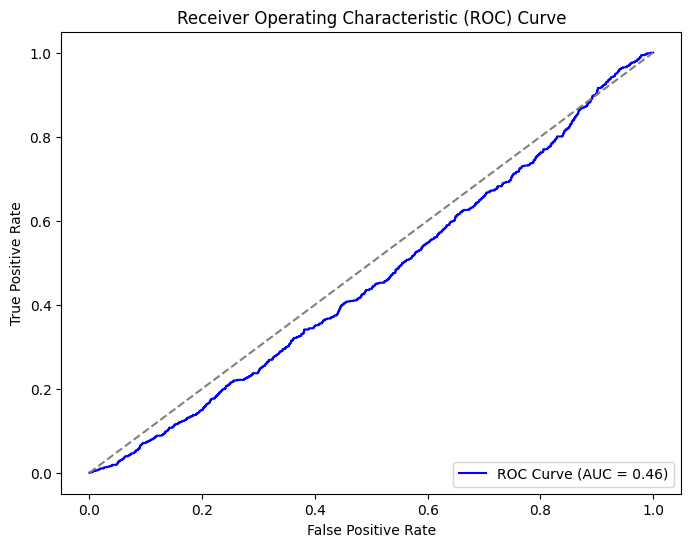

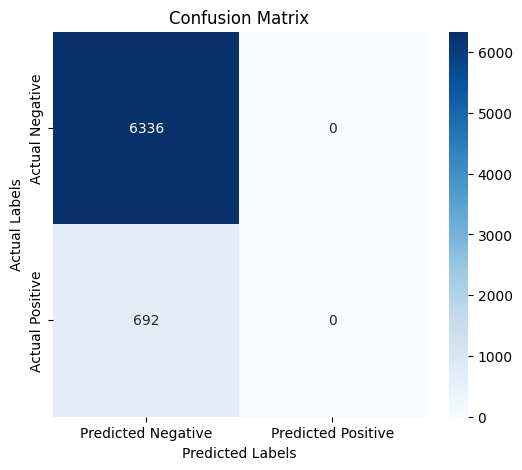

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, accuracy_score)
from sklearn.preprocessing import LabelBinarizer

# Assuming 'model' is your trained model and 'X_test', 'y_test' are your test data and labels

# 1. Obtain predicted probabilities for the positive class
y_probs = model.predict(X_test).flatten() # Adjust indexing if your model has multiple outputs

# 2. Binarize the true labels if they are not already in binary forma

# 3. Compute evaluation metrics
y_pred = (y_probs > 0.5).astype(int)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_probs)
accuracy = accuracy_score(y_test_bin, y_pred)

# 4. Display the metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

# 5. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_bin, y_probs)

# 6. Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# 7. Compute confusion matrix
cm = confusion_matrix(y_test_bin, y_pred)

# 8. Plot confusion matrix using Seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()


## adding location and time information

In [33]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35137 entries, 0 to 35136
Data columns (total 50 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   event_type                              35137 non-null  object 
 1   begin_date_time                         35137 non-null  object 
 2   cz_timezone                             35137 non-null  object 
 3   end_date_time                           35137 non-null  object 
 4   begin_lat                               35137 non-null  float64
 5   begin_lon                               35137 non-null  float64
 6   end_lat                                 35137 non-null  float64
 7   end_lon                                 35137 non-null  float64
 8   extreme                                 35137 non-null  int64  
 9   begin_date_utc                          35137 non-null  object 
 10  begin_time_utc                          35137 non-null  ob

In [35]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, LeakyReLU,
    Dropout, Add, Bidirectional, LSTM, GlobalAveragePooling1D,
    Attention, Dense, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Accuracy, Precision, Recall, AUC

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ========================
# --- Data Preparation ---
# ========================

# Assume merged_df and meteo_cols are defined.
# merged_df should have:
#   - meteo_cols: Your meteorological sequence data (each row: a list structure that you stack later)
#   - "lat" and "lon": Location features.
#   - "begin_datetime": A datetime string column (e.g., "2012-10-29 12:30:00").
#   - "event_type": A categorical event column.
#   - "extreme": A binary target indicating extreme events.

# Convert begin_datetime to datetime and extract time features
merged_df['begin_datetime'] = pd.to_datetime(merged_df['begin_date_time'])
merged_df['hour'] = merged_df['begin_datetime'].dt.hour
# Cyclical encoding for hour (24-hour periodicity)
merged_df['sin_hour'] = np.sin(2 * np.pi * merged_df['hour'] / 24)
merged_df['cos_hour'] = np.cos(2 * np.pi * merged_df['hour'] / 24)
merged_df['dayofweek'] = merged_df['begin_datetime'].dt.dayofweek  # 0=Mon, ... 6=Sun

# List of extra features (time & location)
extra_cols = ['sin_hour', 'cos_hour', 'dayofweek', 'begin_lat', 'begin_lon']
extra_data = merged_df[extra_cols]

# --- Prepare Targets ---
# For the multi-class event type (if needed)
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df["event_type"].values)
num_classes = len(le.classes_)
y_cat = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

# For extreme event (binary target)
y_bin = merged_df["extreme"].values

# --- Prepare Meteorological Sequence Data ---
# meteo_cols is assumed to be a list of column names in merged_df with your sequence information.
# Each row in merged_df[meteo_cols] is expected to be a list (or similar structure) that will later be stacked.
X_seq_raw = merged_df[meteo_cols]

# ----------------------
# --- Data Splitting ---
# ----------------------
# Split based on indices; here we use the extreme label for stratification.
X_seq_train, X_seq_test, y_train_cat, y_test_cat, y_train_bin, y_test_bin = train_test_split(
    X_seq_raw, y_cat, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

X_seq_train, X_seq_val, y_train_bin, y_val_bin = train_test_split(
    X_seq_train, y_train_bin, test_size=0.2, random_state=42, stratify=y_train_bin
)

# Also split extra features using the same indices as for the sequence data
X_extra_train = extra_data.loc[X_seq_train.index].copy()
X_extra_test  = extra_data.loc[X_seq_test.index].copy()
X_extra_val   = extra_data.loc[X_seq_val.index].copy()

# ---------------------------------------------------
# --- Combine Sequence and Extra Data for Oversample ---
# ---------------------------------------------------
# To ensure that oversampling picks the same rows for both branches,
# combine them into one DataFrame. We assume here that X_seq_train contains
# each row as a list (e.g., stored as an object in the DataFrame), so we will not modify it.
# Instead, add the extra features as additional columns.
X_train_combined = X_seq_train.copy()
for col in extra_cols:
    X_train_combined[col] = X_extra_train[col].values

# Apply oversampling on the combined DataFrame based on y_train_bin.
oversample = RandomOverSampler(sampling_strategy='minority', random_state=42)
X_train_comb_res, y_train_bin_res = oversample.fit_resample(X_train_combined, y_train_bin)

print("Percentage of positive instances in training data: ", np.mean(y_train_bin_res))
print("Percentage of positive instances in test data: ", np.mean(y_test_bin))
print("Percentage of positive instances in validation data: ", np.mean(y_val_bin))
print("Class distribution after oversampling:", Counter(y_train_bin_res))

# ---------------------------------------------------
# --- Separate Combined Data Back into Two Parts ---
# ---------------------------------------------------
# For the sequence part, we retrieve the original meteo_cols that are stored as lists.
X_seq_train_res = X_train_comb_res[meteo_cols]

# For the extra features, retrieve the extra_cols.
X_extra_train_res = X_train_comb_res[extra_cols]

# -----------------------------------------------
# --- Process Sequence Data (Stack & Scale) ---
# -----------------------------------------------
# Stack the sequence data: each element in X_seq_train_res is assumed to be a list.
X_train_seq_arr = np.stack(X_seq_train_res.values.tolist(), axis=0)
X_test_seq_arr = np.stack(X_seq_test[meteo_cols].values.tolist(), axis=0)
X_val_seq_arr = np.stack(X_seq_val[meteo_cols].values.tolist(), axis=0)

# For scaling, reshape so each timestep is treated independently.
train_shape = X_train_seq_arr.shape  # (samples, num_features, timesteps)
X_train_seq_flat = X_train_seq_arr.reshape(-1, train_shape[-1])
X_test_seq_flat = X_test_seq_arr.reshape(-1, X_test_seq_arr.shape[-1])
X_val_seq_flat = X_val_seq_arr.reshape(-1, X_val_seq_arr.shape[-1])

scaler_seq = StandardScaler()
X_train_seq_flat = scaler_seq.fit_transform(X_train_seq_flat)
X_test_seq_flat = scaler_seq.transform(X_test_seq_flat)
X_val_seq_flat = scaler_seq.transform(X_val_seq_flat)

# Reshape back to original structure and transpose to (samples, timesteps, features)
X_train_seq_arr = X_train_seq_flat.reshape(train_shape).transpose(0, 2, 1)
X_test_seq_arr = X_test_seq_flat.reshape(X_test_seq_arr.shape).transpose(0, 2, 1)
X_val_seq_arr = X_val_seq_flat.reshape(X_val_seq_arr.shape).transpose(0, 2, 1)

num_timesteps = X_train_seq_arr.shape[1]      # e.g., 72 timesteps
num_sequence_features = X_train_seq_arr.shape[2]  # e.g., 27 features

# -----------------------------------------
# --- Process Extra Features (Scale) ---
# -----------------------------------------
scaler_extra = StandardScaler()
X_train_extra_arr = scaler_extra.fit_transform(X_extra_train_res.values)
X_test_extra_arr  = scaler_extra.transform(X_extra_test.values)
X_val_extra_arr   = scaler_extra.transform(X_extra_val.values)
num_extra_features = X_train_extra_arr.shape[1]  # Should be 5 here

print("X_train_seq shape:", X_train_seq_arr.shape)
print("X_train_extra shape:", X_train_extra_arr.shape)
print("y_train_bin shape:", np.array(y_train_bin_res).shape)

# =========================
# --- Build the Model ---
# =========================

# Sequence Input (meteorological time series)
seq_input = Input(shape=(num_timesteps, num_sequence_features), name='timeseries_input')

# --- CNN Feature Extraction for Sequence Data ---
# Shared Conv Block 1
conv1 = Conv1D(filters=64, kernel_size=3, padding='same')(seq_input)
conv1 = BatchNormalization()(conv1)
conv1 = LeakyReLU(negative_slope=0.01)(conv1)
conv1 = MaxPooling1D(pool_size=2)(conv1)
conv1 = Dropout(0.3)(conv1)

# Shared Conv Block 2
conv2 = Conv1D(filters=128, kernel_size=5, padding='same')(conv1)
conv2 = BatchNormalization()(conv2)
conv2 = LeakyReLU(negative_slope=0.01)(conv2)
conv2 = Dropout(0.3)(conv2)

# Residual Connection from Conv Block 1
shortcut = Conv1D(filters=128, kernel_size=1, padding='same')(conv1)
shortcut = BatchNormalization()(shortcut)
res = Add()([conv2, shortcut])

# Shared Conv Block 3
conv3 = Conv1D(filters=128, kernel_size=7, padding='same')(res)
conv3 = BatchNormalization()(conv3)
conv3 = LeakyReLU(negative_slope=0.01)(conv3)
conv3 = Dropout(0.3)(conv3)

# Shared LSTM Sequence Processing Block
x = Bidirectional(LSTM(128, return_sequences=True))(conv3)
x = Dropout(0.4)(x)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.4)(x)

# Shared Attention Mechanism
attn_out = Attention()([x, x])
shared_features = GlobalAveragePooling1D()(attn_out)

# --- Extra Features Branch (Time & Location) ---
extra_input = Input(shape=(num_extra_features,), name='extra_input')
extra_branch = Dense(32, activation='relu')(extra_input)
extra_branch = BatchNormalization()(extra_branch)
extra_branch = Dropout(0.3)(extra_branch)

# --- Concatenate Both Branches ---
combined_features = Concatenate()([shared_features, extra_branch])

# --- Classification Head for Extreme Event Classification ---
extreme_branch = Dense(64)(combined_features)
extreme_branch = BatchNormalization()(extreme_branch)
extreme_branch = LeakyReLU(negative_slope=0.01)(extreme_branch)
extreme_branch = Dropout(0.5)(extreme_branch)
extreme_output = Dense(1, activation='sigmoid', name='extreme')(extreme_branch)

# --- Create and Compile the Model ---
model = Model(inputs=[seq_input, extra_input], outputs=extreme_output)
optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(
    optimizer=optimizer,
    loss={'extreme': 'binary_crossentropy'},
    metrics={'extreme': [
        Accuracy(name='accuracy'),
        Precision(),
        Recall(),
        AUC(name='roc_auc'),
        AUC(curve='PR', name='pr_auc')
    ]}
)
model.summary()

# --------------------------------------
# --- Callbacks and Class Weight Setup
# --------------------------------------
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_bin_res),
    y=y_train_bin_res
)
class_weight_dict = dict(zip(np.unique(y_train_bin_res), class_weights))

# ------------------------
# --- Train the Model ---
# ------------------------
epochs = 50
batch_size = 32
history = model.fit(
    [X_train_seq_arr, X_train_extra_arr], y_train_bin_res,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=([X_val_seq_arr, X_val_extra_arr], y_val_bin),
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

# Optionally evaluate on test data:
results = model.evaluate([X_test_seq_arr, X_test_extra_arr], y_test_bin, verbose=1)
print("Test results:", results)


Percentage of positive instances in training data:  0.5
Percentage of positive instances in test data:  0.09846328969834946
Percentage of positive instances in validation data:  0.0983635716826752
Class distribution after oversampling: Counter({np.int64(0): 20273, np.int64(1): 20273})
X_train_seq shape: (40546, 72, 27)
X_train_extra shape: (40546, 5)
y_train_bin shape: (40546,)


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ timeseries_input    │ (None, 72, 27)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_39 (Conv1D)  │ (None, 72, 64)    │      5,248 │ timeseries_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 64)    │        256 │ conv1d_39[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_35      │ (None, 72, 64)    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 36, 64)    │          0 │ leaky_re_lu_35[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_79          │ (None, 36, 64)    │          0 │ max_pooling1d_4[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_40 (Conv1D)  │ (None, 36, 128)   │     41,088 │ dropout_79[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 128)   │        512 │ conv1d_40[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_36      │ (None, 36, 128)   │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_41 (Conv1D)  │ (None, 36, 128)   │      8,320 │ dropout_79[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_80          │ (None, 36, 128)   │          0 │ leaky_re_lu_36[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 128)   │        512 │ conv1d_41[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 36, 128)   │          0 │ dropout_80[0][0], │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_42 (Conv1D)  │ (None, 36, 128)   │    114,816 │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 128)   │        512 │ conv1d_42[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_37      │ (None, 36, 128)   │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_81          │ (None, 36, 128)   │          0 │ leaky_re_lu_37[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_8     │ (None, 36, 256)   │    263,168 │ dropout_81[0][0]  │
│ (Bidirectional)     │                   │            │                 

 Total params: 609,729 (2.33 MB)

 Trainable params: 608,641 (2.32 MB)

 Non-trainable params: 1,088 (4.25 KB)

Epoch 1/50
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 102s 69ms/step - accuracy: 0.0000e+00 - loss: 0.8119 - pr_auc: 0.5475 - precision_5: 0.5474 - recall_5: 0.4302 - roc_auc: 0.5542 - val_accuracy: 0.0000e+00 - val_loss: 0.4856 - val_pr_auc: 0.2179 - val_precision_5: 0.1983 - val_recall_5: 0.3761 - val_roc_auc: 0.6784 - learning_rate: 1.0000e-04
Epoch 2/50
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 98s 77ms/step - accuracy: 0.0000e+00 - loss: 0.6988 - pr_auc: 0.6362 - precision_5: 0.5992 - recall_5: 0.5991 - roc_auc: 0.6443 - val_accuracy: 0.0000e+00 - val_loss: 0.6319 - val_pr_auc: 0.2220 - val_precision_5: 0.1609 - val_recall_5: 0.6420 - val_roc_auc: 0.6920 - learning_rate: 1.0000e-04
Epoch 3/50
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 96s 75ms/step - accuracy: 0.0000e+00 - loss: 0.6469 - pr_auc: 0.6844 - precision_5: 0.6414 - recall_5: 0.6494 - roc_auc: 0.6986 - val_accuracy: 0.0000e+00 - val_loss: 0.6699 - val_pr_auc: 0.2397 - val_precision_5: 0.1586 - val_recall_5: 0.7016 - val_roc_auc: 0.7076 - learning_rate: 1.

220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step
Test Accuracy: 0.0986
Test Precision: 0.0984
Test Recall: 0.9986
Test F1-Score: 0.1791
Test ROC AUC: 0.5847


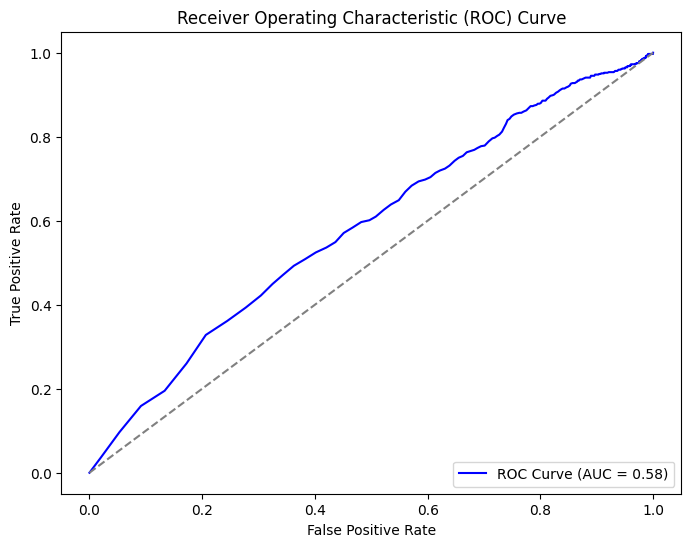

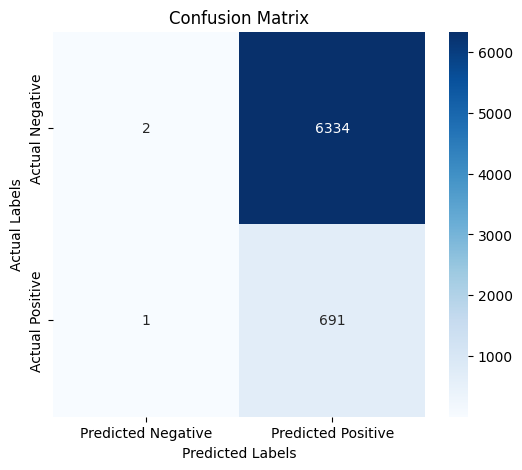

In [38]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, accuracy_score)
from sklearn.preprocessing import LabelBinarizer

# Assuming 'model' is your trained model and 'X_test', 'y_test' are your test data and labels

# 1. Obtain predicted probabilities for the positive class
y_probs = model.predict([X_test_seq_arr, X_extra_test]).flatten() # Adjust indexing if your model has multiple outputs

# 2. Binarize the true labels if they are not already in binary forma

# 3. Compute evaluation metrics
y_pred = (y_probs > 0.5).astype(int)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_probs)
accuracy = accuracy_score(y_test_bin, y_pred)

# 4. Display the metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

# 5. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_bin, y_probs)

# 6. Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# 7. Compute confusion matrix
cm = confusion_matrix(y_test_bin, y_pred)

# 8. Plot confusion matrix using Seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()


## Try Different deep learning models with above processed data at each step like:
1. Train simple neural networks wiht above vairation on the dataset(like with standardization, normalization, PCA, etc.)
2. Try LSTM, GRU, CNN-LSTM, Transformer with proper input features

## Do all the above things with image feature extraction

In [ ]:
import ast
import tensorflow as tf
import pandas as pd

# Example: create a sample DataFrame with a column 'filenames'
data = {
    'filenames': [
        "['event0_Flood_IMERG_Precipitation_Rate_2012-10-29.png', 'event0_Flood_VIIRS_SNPP_Ice_Surface_Temp_Day_2012-10-29.png', 'event0_Flood_VIIRS_SNPP_Ice_Surface_Temp_Night_2012-10-29.png', 'event0_Flood_GHRSST_L4_MUR_Sea_Surface_Temperature_2012-10-29.png', 'event0_Flood_VIIRS_SNPP_Cirrus_Reflectance_SWIR_M11_2012-10-29.png', 'event0_Flood_VIIRS_SNPP_Cirrus_Reflectance_VIS_NIR_2012-10-29.png', 'event0_Flood_CALIPSO_Imaging_Infrared_Radiometer_Brightness_Temperature_Day_CH3_2012-10-29.png', 'event0_Flood_MODIS_Terra_CorrectedReflectance_TrueColor_2012-10-29.png', 'event0_Flood_IMERG_Precipitation_Rate_2012-10-28.png', 'event0_Flood_VIIRS_SNPP_Ice_Surface_Temp_Day_2012-10-28.png', 'event0_Flood_VIIRS_SNPP_Ice_Surface_Temp_Night_2012-10-28.png', 'event0_Flood_GHRSST_L4_MUR_Sea_Surface_Temperature_2012-10-28.png', 'event0_Flood_VIIRS_SNPP_Cirrus_Reflectance_SWIR_M11_2012-10-28.png', 'event0_Flood_VIIRS_SNPP_Cirrus_Reflectance_VIS_NIR_2012-10-28.png', 'event0_Flood_CALIPSO_Imaging_Infrared_Radiometer_Brightness_Temperature_Day_CH3_2012-10-28.png', 'event0_Flood_MODIS_Terra_CorrectedReflectance_TrueColor_2012-10-28.png', 'event0_Flood_IMERG_Precipitation_Rate_2012-10-27.png', 'event0_Flood_VIIRS_SNPP_Ice_Surface_Temp_Day_2012-10-27.png', 'event0_Flood_VIIRS_SNPP_Ice_Surface_Temp_Night_2012-10-27.png', 'event0_Flood_GHRSST_L4_MUR_Sea_Surface_Temperature_2012-10-27.png', 'event0_Flood_VIIRS_SNPP_Cirrus_Reflectance_SWIR_M11_2012-10-27.png', 'event0_Flood_VIIRS_SNPP_Cirrus_Reflectance_VIS_NIR_2012-10-27.png', 'event0_Flood_CALIPSO_Imaging_Infrared_Radiometer_Brightness_Temperature_Day_CH3_2012-10-27.png', 'event0_Flood_MODIS_Terra_CorrectedReflectance_TrueColor_2012-10-27.png']"
    ]
}
df = pd.DataFrame(data)

# Base directory where your images are stored
base_image_path = "/path/to/your/images/"

# Function to convert the string representation to a Python list of filenames.
def parse_filenames(filenames_str):
    # Safely evaluate the string to get the list.
    return ast.literal_eval(filenames_str)

# Function to load and preprocess a single image.
def load_and_preprocess_image(image_path, image_size=(224, 224)):
    # Read the image from disk.
    image = tf.io.read_file(image_path)
    # Decode PNG (or use tf.image.decode_jpeg for jpg).
    image = tf.image.decode_png(image, channels=3)
    # Convert image to floats in range [0, 1].
    image = tf.image.convert_image_dtype(image, tf.float32)
    # Resize the image to the desired dimensions.
    image = tf.image.resize(image, image_size)
    return image

# Function to load all images from the list of filenames and stack them.
def load_images_from_list(filenames_str, base_path=base_image_path, image_size=(224, 224)):
    # Convert string list into actual list of filenames.
    filenames = parse_filenames(filenames_str)
    # Construct full paths and load each image.
    images = []
    for fname in filenames:
        full_path = base_path + fname  # Adjust joining if needed (os.path.join is safer)
        img = load_and_preprocess_image(full_path, image_size)
        images.append(img)
    # Stack into a single tensor with shape (num_images, height, width, channels)
    images_tensor = tf.stack(images)
    return images_tensor

# Test the image loading function on the first row.
example_filenames_str = df.loc[0, 'filenames']
images_tensor = load_images_from_list(example_filenames_str)
print("Shape of loaded images tensor:", images_tensor.shape)

# --------------------------------------------------
# Optional: Building a tf.data Pipeline
# --------------------------------------------------
def process_row(filenames_str):
    # Here, convert the string to a stacked image tensor.
    images_tensor = load_images_from_list(filenames_str)
    # You can further process images_tensor if needed
    # For example, you might want to reshape or merge different days into groups if necessary.
    return images_tensor

# Create a TensorFlow dataset from the 'filenames' column.
filenames_ds = tf.data.Dataset.from_tensor_slices(df['filenames'].tolist())

# Map the dataset to load images
images_ds = filenames_ds.map(lambda x: tf.py_function(func=process_row, inp=[x], Tout=tf.float32))

# For demonstration, iterate through the dataset and print the shape.
for image_tensor in images_ds.take(1):
    print("tf.data loaded images shape:", image_tensor.shape)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dropout,
                                     LSTM, Dense, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model # Import Model for Functional API
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization, Activation,
    LSTM, Bidirectional, Dropout, Dense, LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import relevant metrics for classification, especially if data is imbalanced
from tensorflow.keras.metrics import Precision, Recall, AUC
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Data Preparation ---
# Assume merged_df and meteo_cols are defined earlier in your code.
# For multi-class, we now use the "event_type" column.

# Encode the categorical labels to integer values
le = LabelEncoder()
y_encoded = le.fit_transform(merged_df["event_type"].values)
# Number of classes (should be 10 based on provided counts)
num_classes = len(le.classes_)

# Convert integer labels to one-hot encoded format
y = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)
y_bin = merged_df["extreme"].values # Binary labels for extreme events
# Prepare features (assuming meteo_cols contains your meteorological data)
# Here we simulate stacking the data; adjust if your actual data preprocessing is different.


# Split the data into training and testing sets
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    merged_df[meteo_cols], y,y_bin, test_size=0.2, random_state=42, stratify=y_bin
)


X_train, X_validation, y_train_bin, y_validation_bin = train_test_split(
    X_train,y_train_bin, test_size=0.2, random_state=42, stratify=y_train_bin
)
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
# Apply the oversampling to the dataset
oversample = RandomOverSampler(sampling_strategy='minority', random_state=42)
X_resampled, y_resampled = oversample.fit_resample(X_train,y_train_bin)


X_resampled = np.stack(X_resampled[meteo_cols].values.tolist(), axis=0)
X_test = np.stack(X_test[meteo_cols].values.tolist(), axis=0)
X_validation = np.stack(X_validation[meteo_cols].values.tolist(), axis=0)
# Initialize the RandomOverSampler

print("peecentage of positice instance in training data: ", sum(y_resampled)/len(y_resampled))
print("percentage of positice instance in test data: ", sum(y_test_bin)/len(y_test_bin))
print("percentage of positice instance in validation data: ", sum(y_validation_bin)/len(y_validation_bin))

print("y resampled shape:", y_resampled.shape)
# Display class distribution after oversampling
print("Class distribution after oversampling:", Counter(y_resampled))
# Scale the data
scaler = StandardScaler()

# Reshape for scaling: combine timesteps and features
X_resampled = X_resampled.reshape(-1, X_resampled.shape[-1])
X_test = X_test.reshape(-1, X_test.shape[-1])
X_validation = X_validation.reshape(-1, X_validation.shape[-1])
# Fit and transform
print("X resampled shape before scaling:", X_resampled.shape)
X_resampled = scaler.fit_transform(X_resampled)
X_test = scaler.transform(X_test)
X_validation = scaler.transform(X_validation)
# Reshape back to original structure: (samples, num_features, num_timesteps)
# Note: Here we assume the original shape was (samples, num_features, num_timesteps).
# Adjust reshaping if your data dimensions differ.
X_resampled = X_resampled.reshape(-1, 27, 72)
X_test = X_test.reshape(-1, 27, 72)
X_validation = X_validation.reshape(-1, 27, 72)
# Print shapes to verify correctness (should print something like (samples, 27, 72) and (samples, num_classes))
print("X_train shape:", X_resampled.shape)
print("y_train shape:", y_resampled.shape)

# --- Reshape Input for Model ---
# Rearranging shape to (samples, timesteps, features), here timesteps=72 and features=27.
X_resampled = X_resampled.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)
X_validation = X_validation.transpose(0, 2, 1)
num_timesteps = X_resampled.shape[1]  # should be 72
num_features  = X_resampled.shape[2]  # should be 27
input_layer = Input(shape=(num_timesteps, num_features))
# --- CNN Feature Extraction Block ---
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Dense, Bidirectional, LSTM, GlobalAveragePooling1D, Attention
from tensorflow.keras.optimizers import Adam






import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, LeakyReLU, MaxPooling1D, Dropout, Add, Bidirectional, LSTM, Attention, GlobalAveragePooling1D, Dense, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, Conv2D, BatchNormalization, LeakyReLU, 
                                     MaxPooling1D, MaxPooling2D, Dropout, Add, Bidirectional, 
                                     LSTM, Attention, GlobalAveragePooling1D, GlobalAveragePooling2D, 
                                     Dense, concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ---------------------------
# Weather Data Branch
# ---------------------------
# For example, assume weather data is a sequence of 100 timesteps with 64 features.
weather_input = Input(shape=(100, 64), name='weather_input')

# Conv Block 1
w = Conv1D(filters=64, kernel_size=3, padding='same')(weather_input)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = MaxPooling1D(pool_size=2)(w)
w = Dropout(0.3)(w)

# Conv Block 2
w = Conv1D(filters=128, kernel_size=5, padding='same')(w)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = Dropout(0.3)(w)

# Residual Connection from Block 1
shortcut = Conv1D(filters=128, kernel_size=1, padding='same')(weather_input[:, :weather_input.shape[1]//2, :])
shortcut = BatchNormalization()(shortcut)
w = Add()([w, shortcut])

# Conv Block 3
w = Conv1D(filters=128, kernel_size=7, padding='same')(w)
w = BatchNormalization()(w)
w = LeakyReLU(alpha=0.01)(w)
w = Dropout(0.3)(w)

# LSTM and Attention
w = Bidirectional(LSTM(128, return_sequences=True))(w)
w = Dropout(0.4)(w)
w = Bidirectional(LSTM(64, return_sequences=True))(w)
w = Dropout(0.4)(w)
w = Attention()([w, w])
weather_features = GlobalAveragePooling1D()(w)

# ---------------------------
# Image Data Branch (Feature Extraction)
# ---------------------------
# For example, assume raw images are of shape (224, 224, 3)
image_input = Input(shape=(224, 224, 3), name='image_input')

# Custom CNN for feature extraction
i = Conv2D(32, kernel_size=(3,3), padding='same')(image_input)
i = BatchNormalization()(i)
i = LeakyReLU(alpha=0.01)(i)
i = MaxPooling2D(pool_size=(2,2))(i)
i = Dropout(0.3)(i)

i = Conv2D(64, kernel_size=(3,3), padding='same')(i)
i = BatchNormalization()(i)
i = LeakyReLU(alpha=0.01)(i)
i = MaxPooling2D(pool_size=(2,2))(i)
i = Dropout(0.3)(i)

i = Conv2D(128, kernel_size=(3,3), padding='same')(i)
i = BatchNormalization()(i)
i = LeakyReLU(alpha=0.01)(i)
i = MaxPooling2D(pool_size=(2,2))(i)
i = Dropout(0.3)(i)

# Global pooling to reduce to feature vector
i = GlobalAveragePooling2D()(i)
# Optional fully connected layer to further process image features
img_features = Dense(128, activation='relu')(i)
img_features = BatchNormalization()(img_features)
img_features = Dropout(0.4)(img_features)

# ---------------------------
# Merge Branches and Build Final Classification Head
# ---------------------------
# Merge the weather and image features
combined_features = concatenate([weather_features, img_features], name='combined_features')

# Fully connected layers for extreme event classification
x = Dense(64)(combined_features)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.01)(x)
x = Dropout(0.5)(x)
extreme_output = Dense(1, activation='sigmoid', name='extreme')(x)

# Define the complete multi-modal model
model = Model(inputs=[weather_input, image_input], outputs=extreme_output)

# Compile the model with Adam optimizer and binary cross-entropy loss
optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=[tf.keras.metrics.Accuracy(name='accuracy'),
                       tf.keras.metrics.Precision(),
                       tf.keras.metrics.Recall(),
                       tf.keras.metrics.AUC(name='roc_auc'),
                       tf.keras.metrics.AUC(curve='PR', name='pr_auc')])

# Display the model summary
model.summary()



# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# --- Class Weights ---
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',   # This option adjusts weights inversely proportional to class frequencies in the input data
    classes=np.unique(y_resampled),  # List of unique class labels
    y=y_resampled  # Your target variable (e.g., labels)
)

# Convert class_weights to a dictionary format
class_weight = dict(zip(np.unique(y_resampled), class_weights))
# --- Train the Model ---
epochs = 50
batch_size = 32
print("y resampe shape", y_resampled.shape)
history_1 = model.fit(X_resampled,  y_resampled,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.2,
                    callbacks=[early_stopping, reduce_lr],
                    validation_data=(X_validation, y_validation_bin),
                    class_weight=class_weight,
                    verbose=1)




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35137 entries, 0 to 35136
Data columns (total 55 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   event_type                              35137 non-null  object        
 1   begin_date_time                         35137 non-null  object        
 2   cz_timezone                             35137 non-null  object        
 3   end_date_time                           35137 non-null  object        
 4   begin_lat                               35137 non-null  float64       
 5   begin_lon                               35137 non-null  float64       
 6   end_lat                                 35137 non-null  float64       
 7   end_lon                                 35137 non-null  float64       
 8   extreme                                 35137 non-null  int64         
 9   begin_date_utc                          35137 non-

## Do all the above things with finetuning a good pretrained image model

## Do all the above things without finetuning but with CNN model from scratch

## Try Forecasting + Binary classification and anomaly detection